In [5]:
import os 

#Insert API key
# os.environ['OPENAI_API_KEY'] = 'sk-GSJA3k3Re1j05j0K7es3oumDBFJl5C8kn8ronDnqPmOenE5G'
os.environ['OPENAI_API_KEY'] = 'sk-5T6oMdbJnNP23WEC5psT4I8sZyEd90Nve1YquVKdj9coHpIy'
os.environ['OPENAI_API_BASE'] = 'https://api.chatanywhere.org/v1'
# os.environ['http_proxy'] = 'http://127.0.0.1:7890'
# os.environ['https_proxy'] = 'https://127.0.0.1:7890'

In [6]:
import sys
sys.path.append("../")

#Import your prompt - we have a system message, starting prompt and iteration prompt
# ADSC is hard search with all operators (A), 
# and all tools (D (data), C (context), S (scratchpad))

from prompt_airfog import SYS_MSG, IGNITE, ITER


In [7]:
#Import experiment class
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#experiment file all different experiment settings in Python class
from experiment import airFog

In [8]:
#Import data
from load_data import load_data

indep_vars, dep_vars = load_data('../AirFogSim/output/global_data.csv')

In [5]:
# Without context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and uavs collaborate to complete computational tasks under limited bandwidth and computational resources  
For each time slot, key indicators, such as task success ratio, average V2U rate, and UAV density, are recorded. 
The 3 patterns you need to analyze are all about the relationship between one key indicator of the next slot and a few key indicators of the current slot.

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, average V2U density, average compute load and the previous average compute load. 
- Independent variable (x1): Current task success ratio
- Independent variable (x2): Current vehicle density
- Independent variable (x3): Current average V2U density
- Independent variable (x4): Average compute load at the current time slot (i.e., y_t)
- Independent variable (x5): Average compute load at the previous time slot (i.e., y_{t-1})
- Dependent variable (y): Average compute load at the next time slot (i.e., y_{t+1})

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
"""

In [9]:
# With context augmentation
context = """
The data is collected from a low-altitude vehicular network where vehicles and UAVs collaborate to complete computational tasks under limited bandwidth and computational resources.

Key indicators—such as task success ratio, V2U rate, and UAV density—are recorded at each time slot. Predictive patterns describe the relationship between next-slot outcomes and current-slot indicators.

Supplementary System Context:
- Simulated system includes 50 vehicles, 30 UAVs, 8 RSUs, and 1 cloud center
- Total 370 CPU units: vehicle (2), UAV (3), RSU (10), cloud (100)
- Tasks follow Poisson process (λ=0.5), with size 0.2–0.7, deadlines 1–2s
- UAVs fly at 100m, communicate within 150m
- Map has 126 junctions, 244 edges; 5 key junctions with 8 connected roads & traffic lights
- 2 no-fly zones (total 80,000 m², ~1.1%) impact UAV routes
- UAVs and vehicles cluster near [1000, 1500, 2000]m, often around RSUs
- Vehicle density increases; UAV density remains stable → affects routing & load
- Intersections with traffic control shape congestion and movement
- Simulation proceeds in 10-second slots; indicators logged per interval
- UAV mobility limited by no-fly zones and obstacles; vehicles aggregate at junctions, RSUs, task sources

Pattern 1: Predict the average compute load of the next time slot based on the current task success ratio, vehicle density, average V2U density, average compute load and the previous average compute load. 
- Independent variable (x1): Current task success ratio
- Independent variable (x2): Current vehicle density
- Independent variable (x3): Current average V2U density
- Independent variable (x4): Average compute load at the current time slot (i.e., y_t)
- Independent variable (x5): Average compute load at the previous time slot (i.e., y_{t-1})
- Dependent variable (y): Average compute load at the next time slot (i.e., y_{t+1})
Note:  
Compute load is influenced by task arrival rate (Poisson, λ=0.5), CPU capacities (vehicle: 2, UAV: 3, RSU: 10), and traffic congestion around key junctions. It shows complex oscillating and delayed behavior.
Please consider containing following structures in your expressions:
- Polynomial terms (e.g., x1², x2³)
- Exponential and logarithmic transformations
- Cross-variable interactions (e.g., x1 * x3, x2 / x4)
- Temporal modeling elements:
  - Moving average: movavg(x1, 3)
  - Residual dynamics: x1 - x2
  - State memory: x4, x5, (x4 - x5)

Pattern 2: Predict the average V2U rate of the next time slot based on the current vehicle density, UAV density and compute load.
- Independent variable (x1): Current vehicle density.
- Independent variable (x2): Current UAV density.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Average V2U rate of the next time slot.
Note: V2U communication is influenced by UAV density, vehicle distribution, and spatial constraints. UAVs operate at 100 meters altitude and have a communication range of 150 meters. There are 8 RSUs distributed across the area, which affects link availability.

Pattern 3: Predict the task success ratio of the next time slot based on the current average V2U rate, average V2I rate and compute load.
- Independent variable (x1): Current average V2U rate.
- Independent variable (x2): Current average V2I rate.
- Independent variable (x3): Current average compute load.
- Dependent variable (y): Task success ratio of the next time slot.
Note: Task success ratio is constrained by deadline (TTL 1–2s), link latency, and current compute load saturation across UAVs and RSUs. It must be in range [0, 1]. It is sensitive to bandwidth availability and processing load. Empirical observations show:
- When bandwidth is insufficient, task success sharply declines.
- When compute load nears saturation, task success drops abruptly.
- The y-value (success ratio) non-linearly changes with respect to x1–x3.
Please consider containing following structures in your expressions:
- Sigmoid-like structures to model saturating effects:  
  `y = 1 / (1 + exp(-...))`  
  `y = min(1, max(0, ...))`
- Load penalty: include inverse terms like `1 / (x3 + c)` or log-shifted forms like `log(x3 + 1)`
- Bandwidth interplay: try cross-variable interactions such as `x1 * x2` or `x1 / (x2 + 1)`
- Saturation indicators: consider residuals or thresholding functions for compute load
- Simpler alternatives: linear combinations, squares or square roots of x1/x2 if it captures the trend
- Avoid always returning expressions that collapse to ~0.5.
"""

Running experiment 1...


d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:26: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  self.llm = ChatOpenAI(temperature=temp, model=model)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:36: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.equation_generation_chain = LLMChain(llm=self.llm, prompt=self.startup_promt)
d:\Junior\MajorProject\Low-Dynamic-Traffic-Analysis\Prediction\experiment.py:61: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will b

Give up equations whose nmae > 0.5: []
Give up equations whose nmae > 0.5: []
Give up equations whose nmae > 0.5: [{'equation': '1/(1+exp(c[0]*x3-c[1]*x1*x2))', 'complexity': 14, 'nmae': np.float64(0.5526863856919332), 'fitted_params': [-4.999977770723785, 4.301871049505871]}, {'equation': 'min(1,max(0,x1*x2/(x3+c[0])))', 'complexity': 7, 'nmae': np.float64(0.8067799804775053), 'fitted_params': [0.10811873560247598]}]


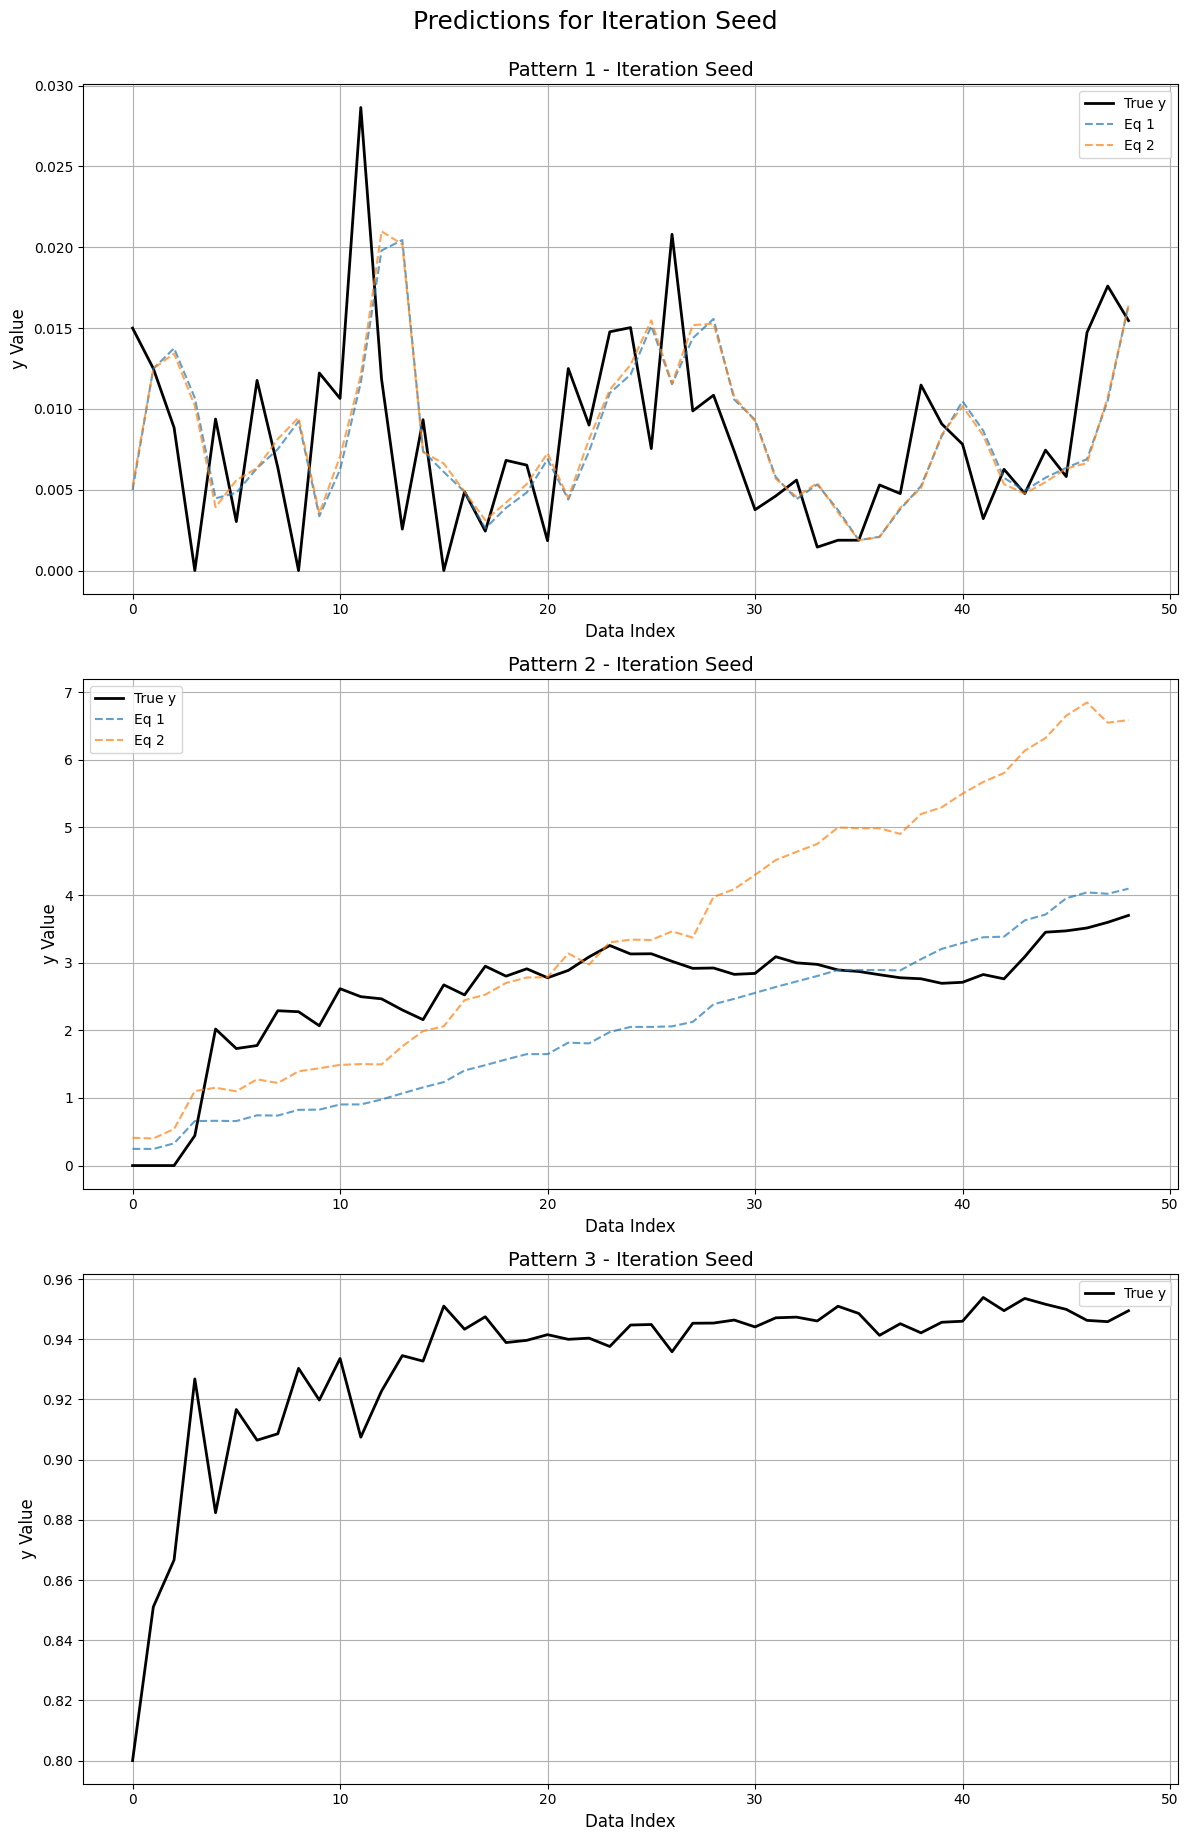

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

**Pattern 1 Analysis (Avg Compute Load Prediction):**  
- Inputs: x1 (task success ratio), x2 (vehicle density), x3 (V2U density), x4 (current load), x5 (previous load)  
- Output y = load at t+1  
- Oscillating and delayed behavior → temporal modeling matters  
- Expect influence from x4 and x5 (state memory), and residual x4 - x5  
- x2 is monotonically increasing → could dominate if not treated cautiously  
- x3 is V2U density, may have a subtle effect  
- x1 likely has an indirect influence via task success  
- Try polynomial x2², log(x2), interaction x1 * x3, etc.  

Candidate expressions:
- Use residuals (x4 - x5), moving avg of x1 or x4  
- Model stabilization by decay or averaging  
- Combine direct load input (x4) with shift or residuals  

**Pattern 2 Analysis (Avg V2U Rate Prediction):**  
- Inputs: x1 (vehicle density), x2 (UAV density, constant), x3 (compute load)  
- Output y = V2U rat

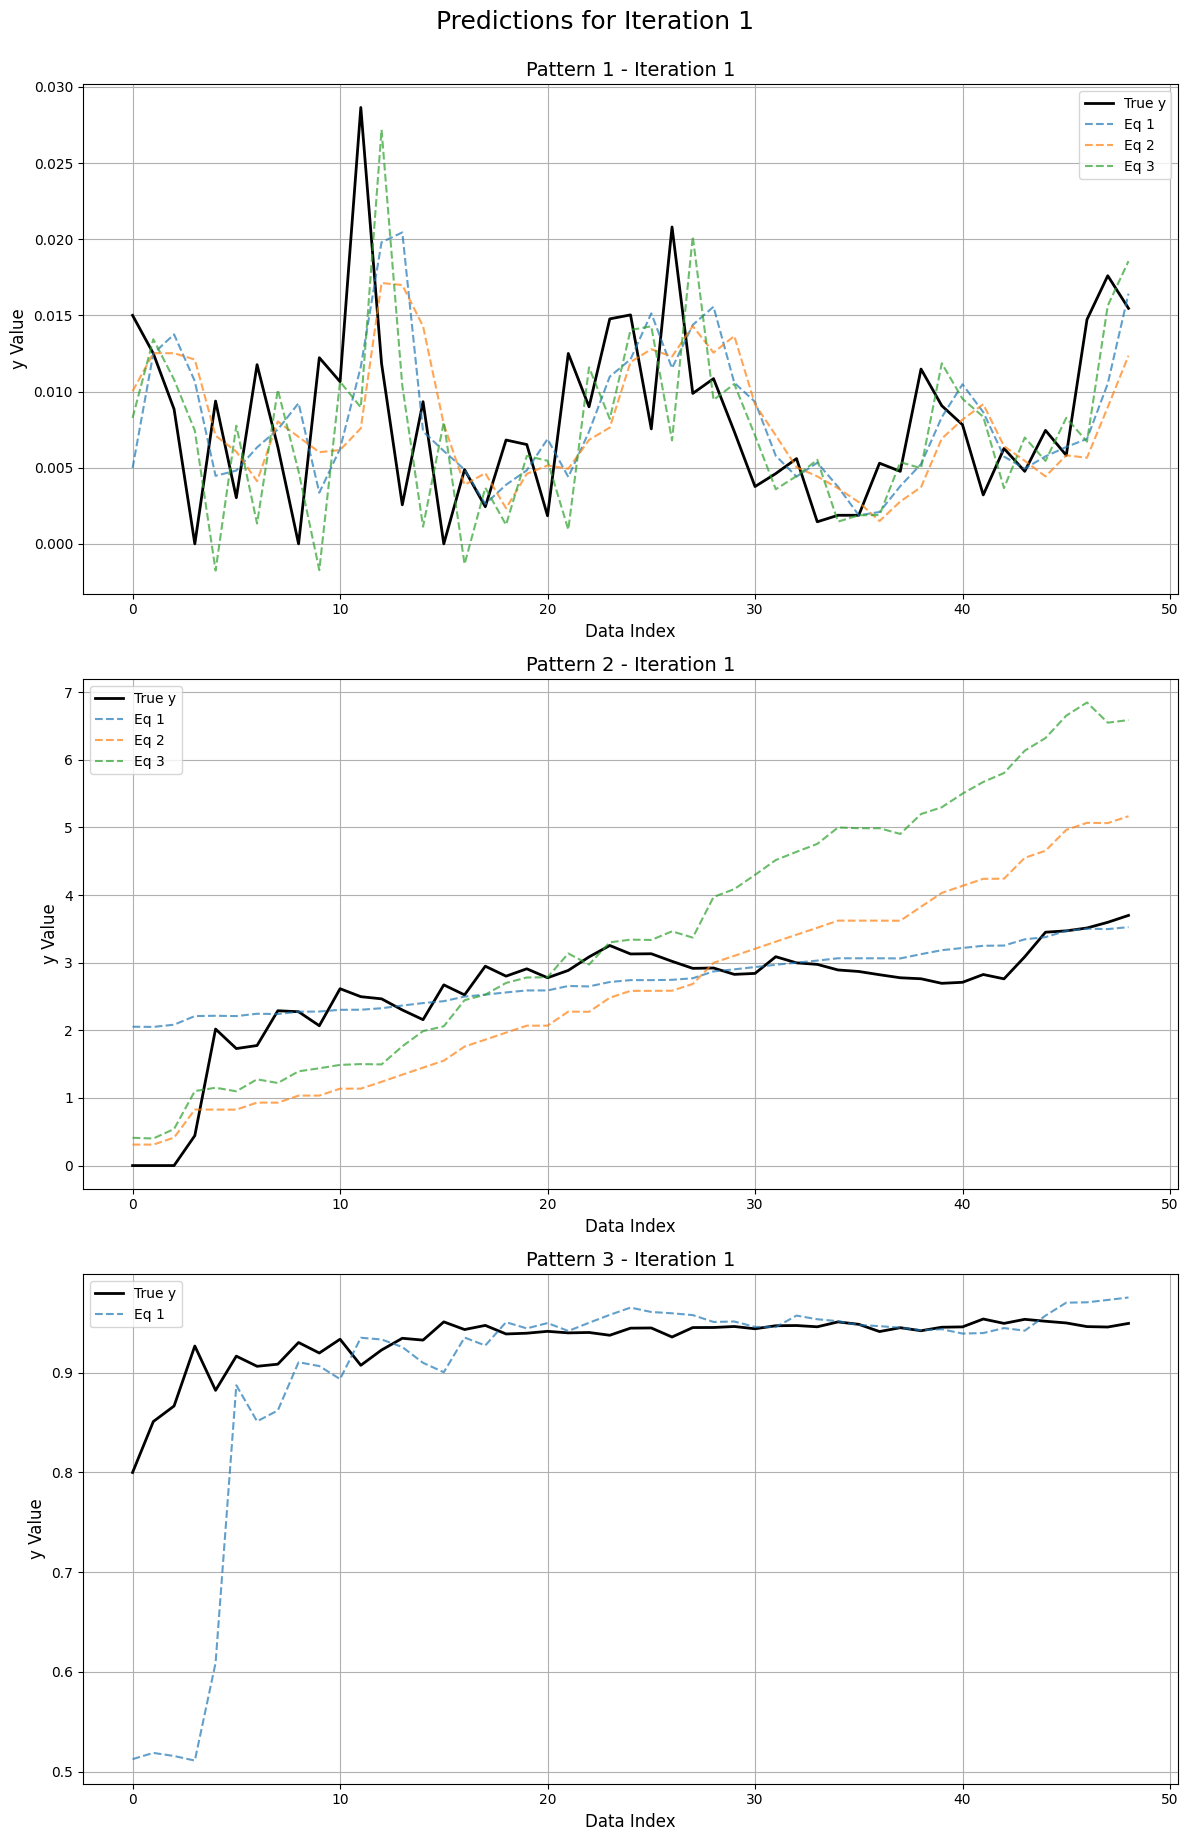

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x4-x5)+c[1]*x1*x3', 'complexity': 13, 'nmae': np.float64(0.1564546886955914), 'fitted_params': [-0.5013895457192495, 7.812774653277568e-05]}, {'equation': 'x4+c[0]*x1-c[1]*x2+c[2]*x3+c[3]*(x4-x5)', 'complexity': 19, 'nmae': np.float64(0.15640860945618146), 'fitted_params': [-0.00014487362816773013, 0.00018278413193480698, 0.00043417478393101684, -0.4610616882610944]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*x1*x3', 'complexity': 13, 'nmae': np.float64(0.15645468768258627), 'fitted_params': [-0.5013854191633238, 7.812573374616549e-05]}, {'equation': 'movavg(4, 3)+c[0]*(x1-x2)', 'complexity': 7, 'nmae': np.float64(0.16130577555886136), 'fitted_params': [5.799245012485999e-05]}, {'equation': 'x4+c[0]*x1**2+c[1]*(x2/(x3+c[2]))', 'complexity': 15, 'nmae': np.float64(0.17951677288438364), 'fitted_params': [-0.0029021951265741953, 0.0067190168750656774, 9.99822165582014]}], [{'equation': 'x1/(x3+c[0])', 'complexity': 5, '

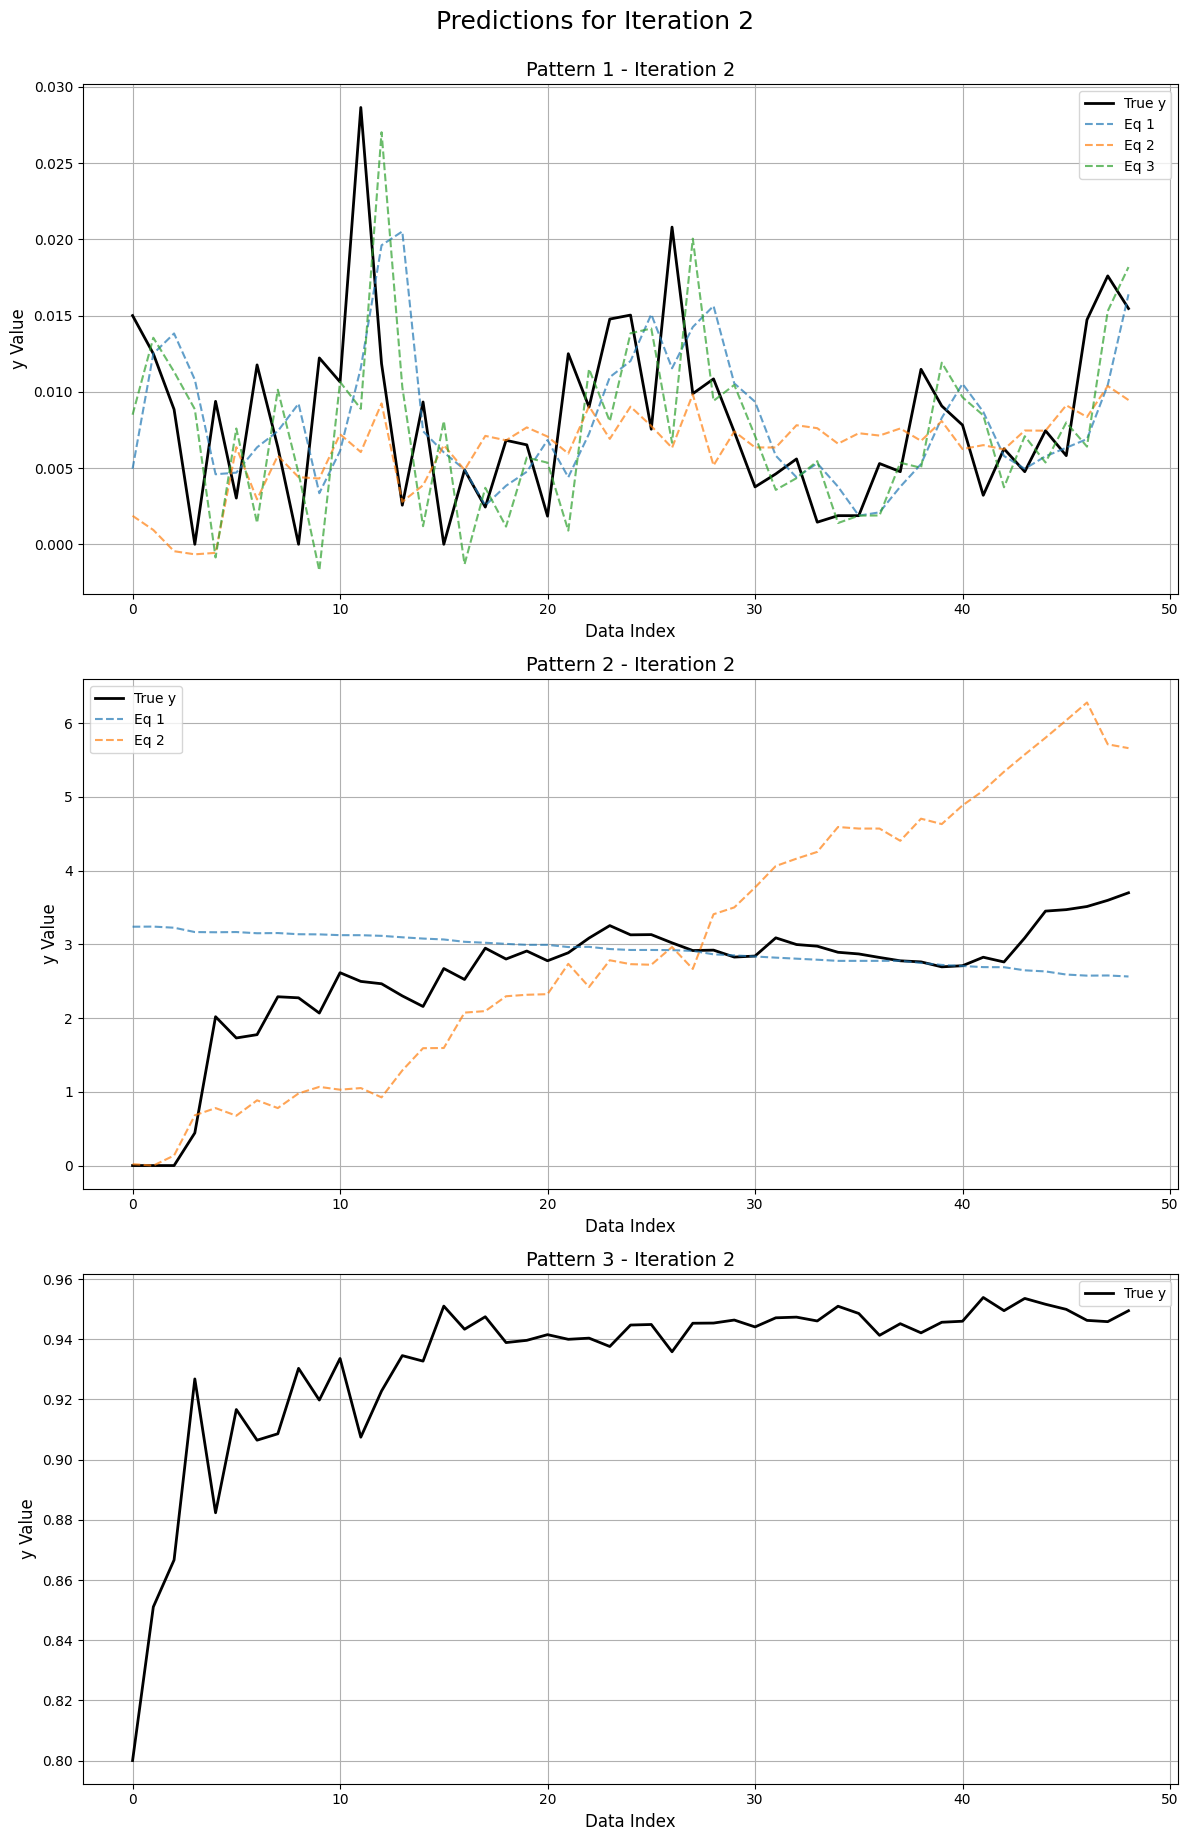

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*x1**2+c[1]*(x2/(x3+c[2]))', 'complexity': 15, 'nmae': np.float64(0.17951677288438364), 'fitted_params': [-0.0029021951265741953, 0.0067190168750656774, 9.99822165582014]}, {'equation': 'movavg(4, 3)+c[0]*(x1-x2)', 'complexity': 7, 'nmae': np.float64(0.16130577555886136), 'fitted_params': [5.799245012485999e-05]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021721019464), 'fitted_params': [-0.5087327722498003, 0.00012130080575827417]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*x1*x3', 'complexity': 13, 'nmae': np.float64(0.15645468768258627), 'fitted_params': [-0.5013854191633238, 7.812573374616549e-05]}, {'equation': 'x4+c[0]*x1-c[1]*x2+c[2]*x3+c[3]*(x4-x5)', 'complexity': 19, 'nmae': np.float64(0.15640860945618146), 'fitted_params': [-0.00014487362816773013, 0.00018278413193480698, 0.00043417478393101684, -0.4610616882610944]}], [{'equation': 'x1*exp(-c[0]*x3)', 'complexi

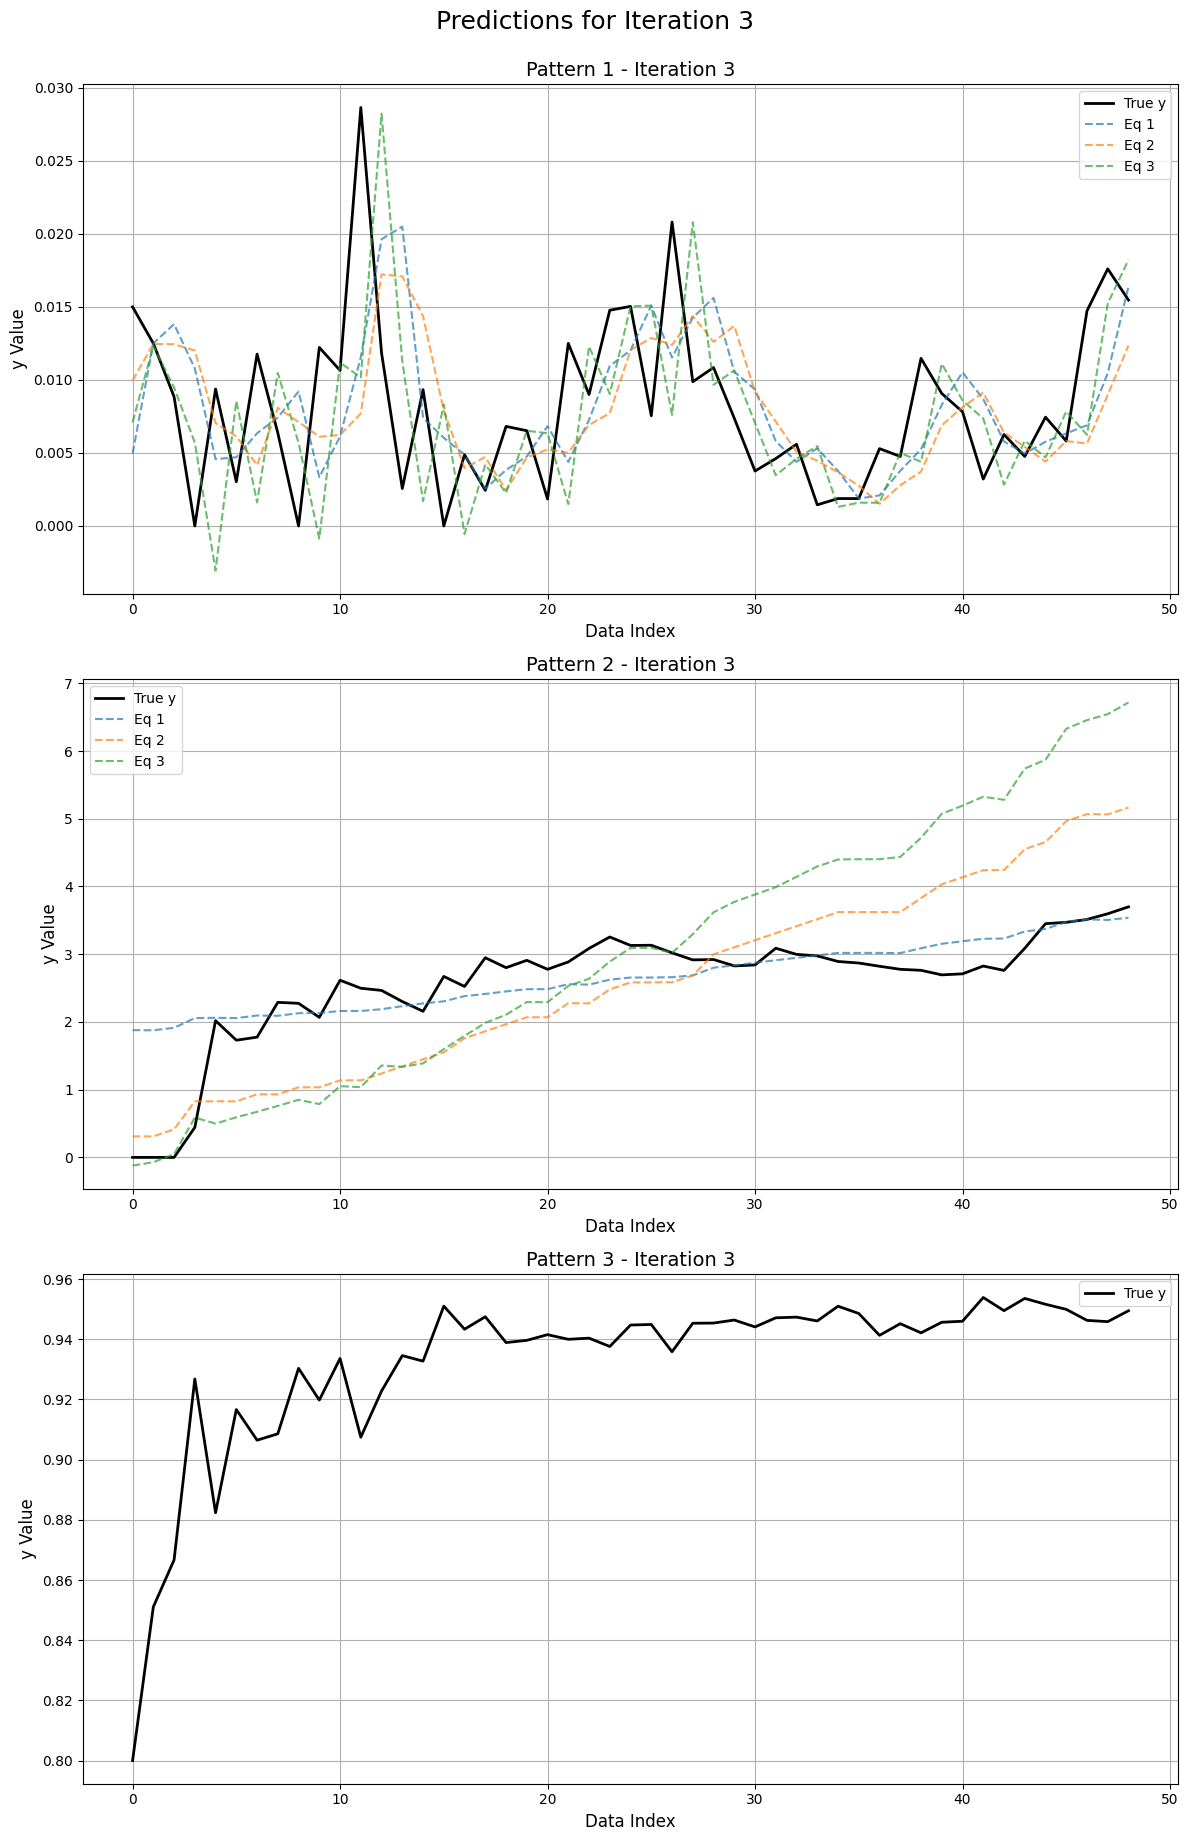

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*x1**2+c[1]*(x2/(x3+c[2]))', 'complexity': 15, 'nmae': np.float64(0.17951677288438364), 'fitted_params': [-0.0029021951265741953, 0.0067190168750656774, 9.99822165582014]}, {'equation': 'x4+c[0]*x1**2+c[1]*x3', 'complexity': 11, 'nmae': np.float64(0.1774270930959979), 'fitted_params': [-0.0041747337911994704, 0.001208063928535504]}, {'equation': 'movavg(4, 3)+c[0]*(x1-x2)', 'complexity': 7, 'nmae': np.float64(0.16130577555886136), 'fitted_params': [5.799245012485999e-05]}, {'equation': 'movavg(4, 3)+c[0]*(x1*x3-x2)', 'complexity': 9, 'nmae': np.float64(0.16121827301850383), 'fitted_params': [9.534770575525542e-05]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021721019464), 'fitted_params': [-0.5087327722498003, 0.00012130080575827417]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*x1*log(x2+1)', 'complexity': 16, 'nmae': np.float64(0.1564921085910539), 'fitted_params': [-0.50

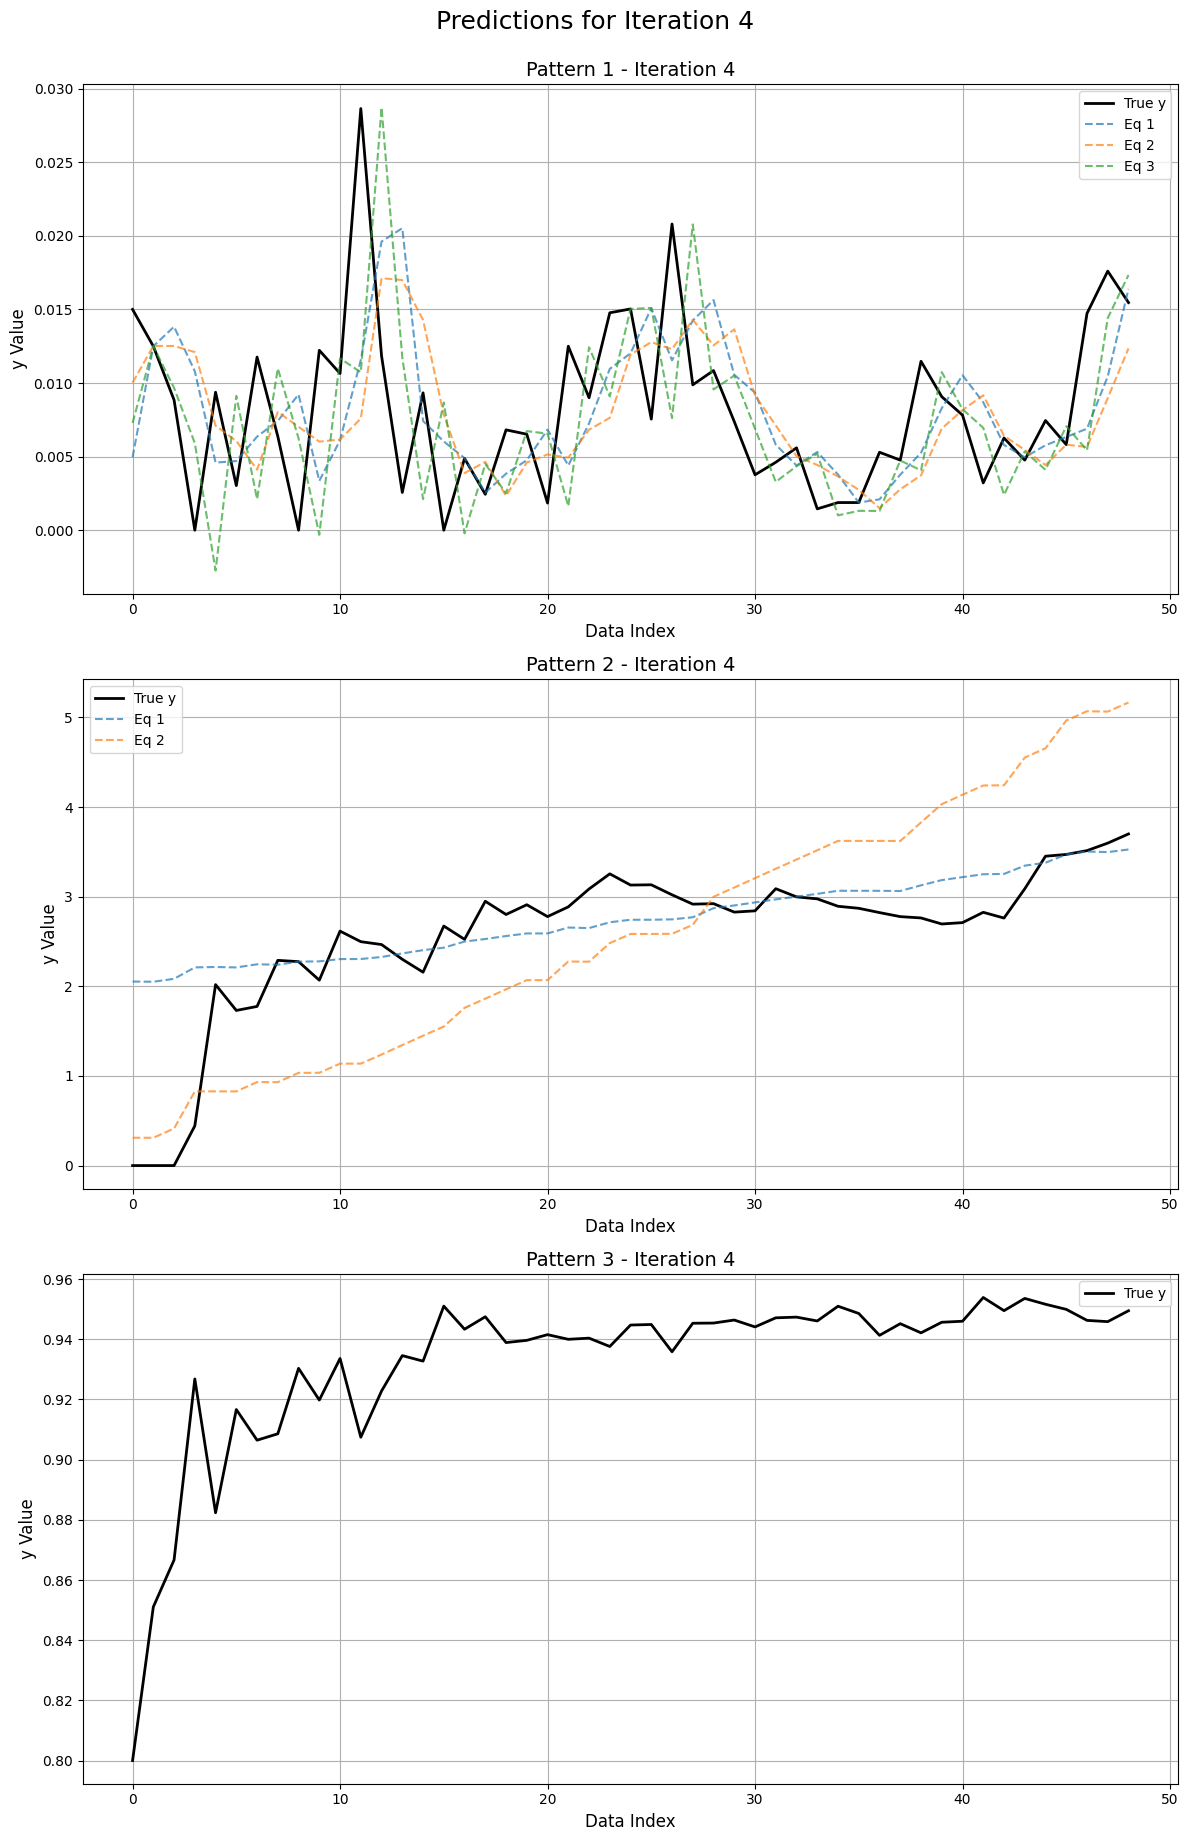

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*x1**2+c[1]*x3/(x2+c[2])', 'complexity': 15, 'nmae': np.float64(0.17848158662016755), 'fitted_params': [-0.003906253440409702, 0.01543904915208407, 9.999473488784203]}, {'equation': 'x4+c[0]*x1**2+c[1]*x3', 'complexity': 11, 'nmae': np.float64(0.1774270930959979), 'fitted_params': [-0.0041747337911994704, 0.001208063928535504]}, {'equation': 'movavg(4, 3)+c[0]*(x1-x2)', 'complexity': 7, 'nmae': np.float64(0.16130577103481997), 'fitted_params': [5.799712523064988e-05]}, {'equation': 'movavg(4, 3)+c[0]*(x1*x3-x2)', 'complexity': 9, 'nmae': np.float64(0.16121827301850383), 'fitted_params': [9.534770575525542e-05]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021721019464), 'fitted_params': [-0.5087327722498003, 0.00012130080575827417]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*x1*log(x2+1)', 'complexity': 16, 'nmae': np.float64(0.1564921085910539), 'fitted_params': [-0.507304

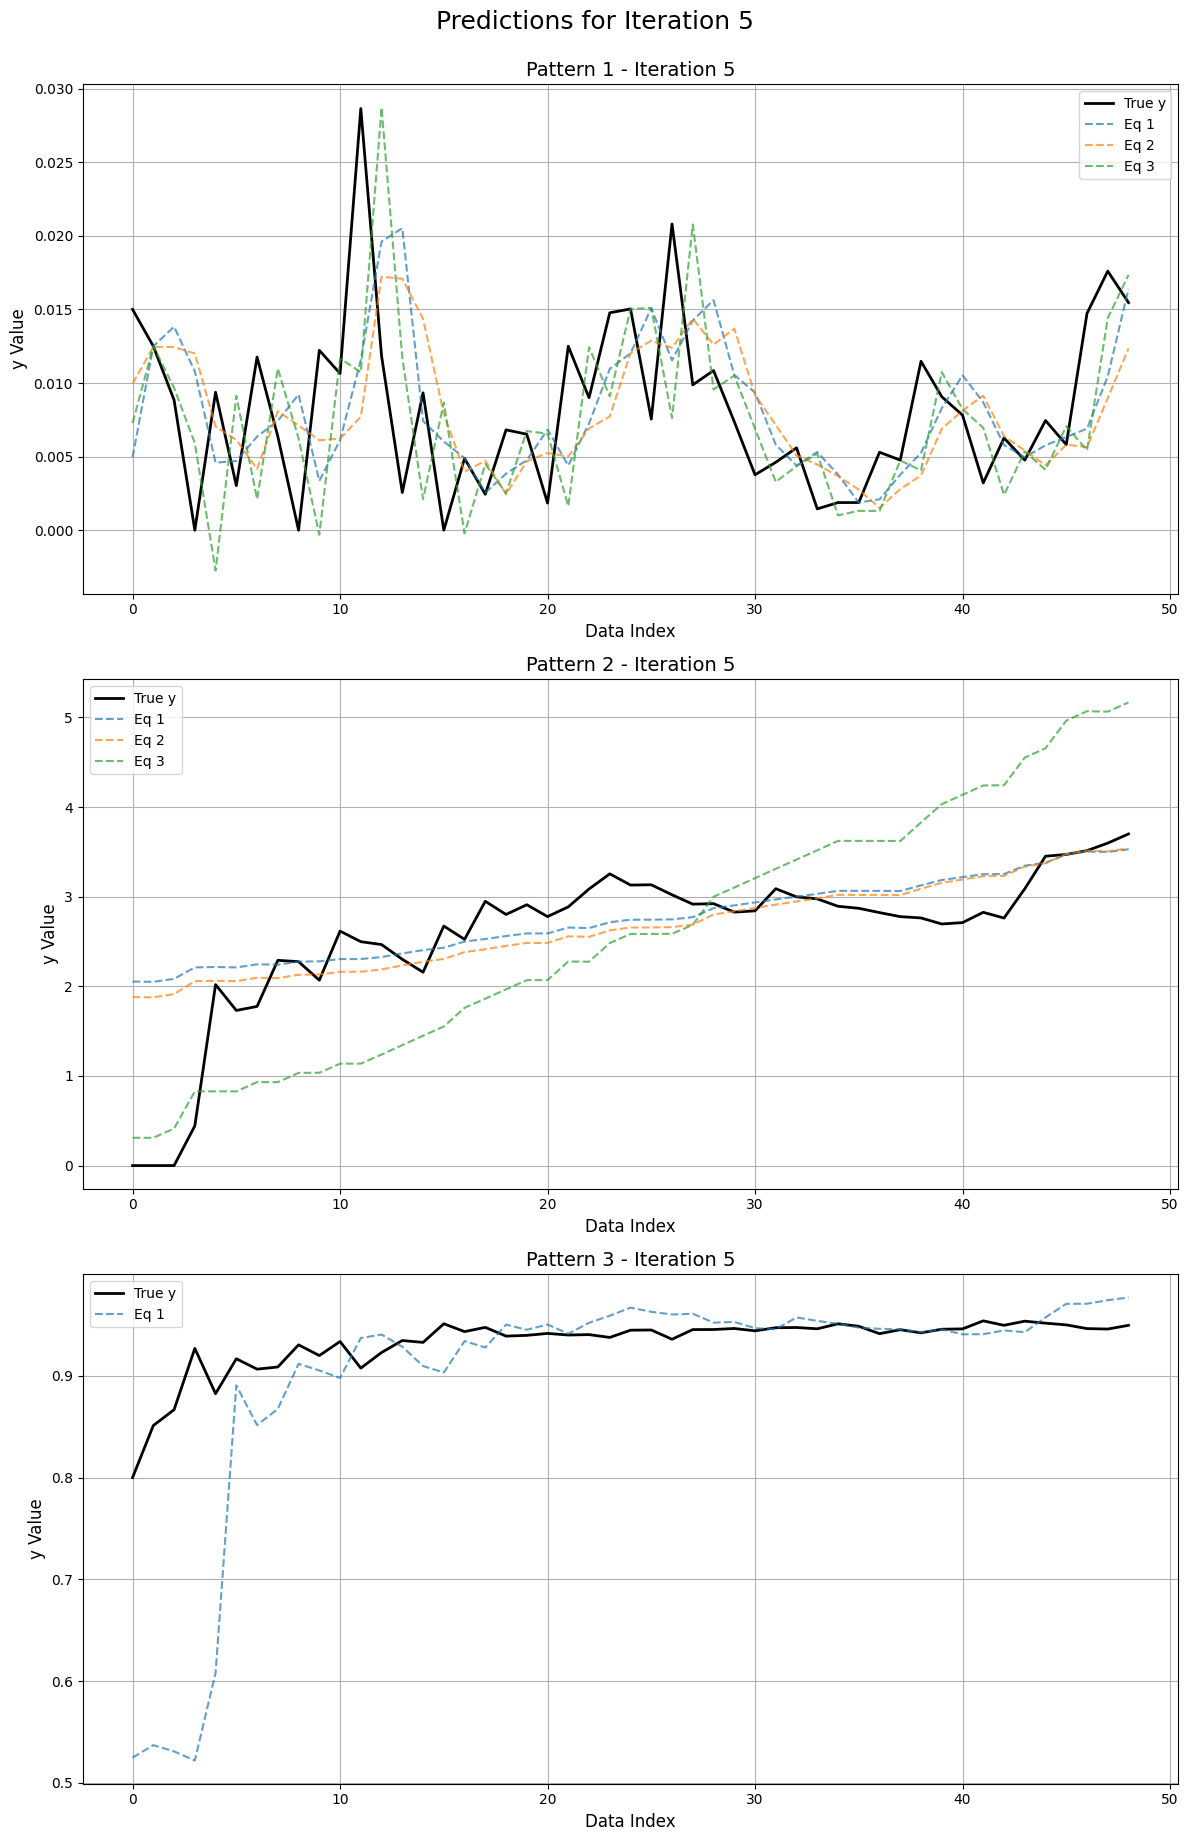

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*x1**2+c[1]*x3/(x2+c[2])', 'complexity': 15, 'nmae': np.float64(0.1784815348178394), 'fitted_params': [-0.0039063020139111695, 0.01543989667684179, 9.999930555434599]}, {'equation': 'x4+c[0]*x1**2+c[1]*x3', 'complexity': 11, 'nmae': np.float64(0.1774270930959979), 'fitted_params': [-0.0041747337911994704, 0.001208063928535504]}, {'equation': 'movavg(4, 3)+c[0]*(x1-x2)', 'complexity': 7, 'nmae': np.float64(0.16130577103481997), 'fitted_params': [5.799712523064988e-05]}, {'equation': 'movavg(4, 3)+c[0]*(x1*x3-x2)', 'complexity': 9, 'nmae': np.float64(0.16121827301850383), 'fitted_params': [9.534770575525542e-05]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.15650216631795055), 'fitted_params': [-0.5087011841638219, 0.00012129160190039944]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*x1*log(x2+1)', 'complexity': 16, 'nmae': np.float64(0.1564921085910539), 'fitted_params': [-0.50730

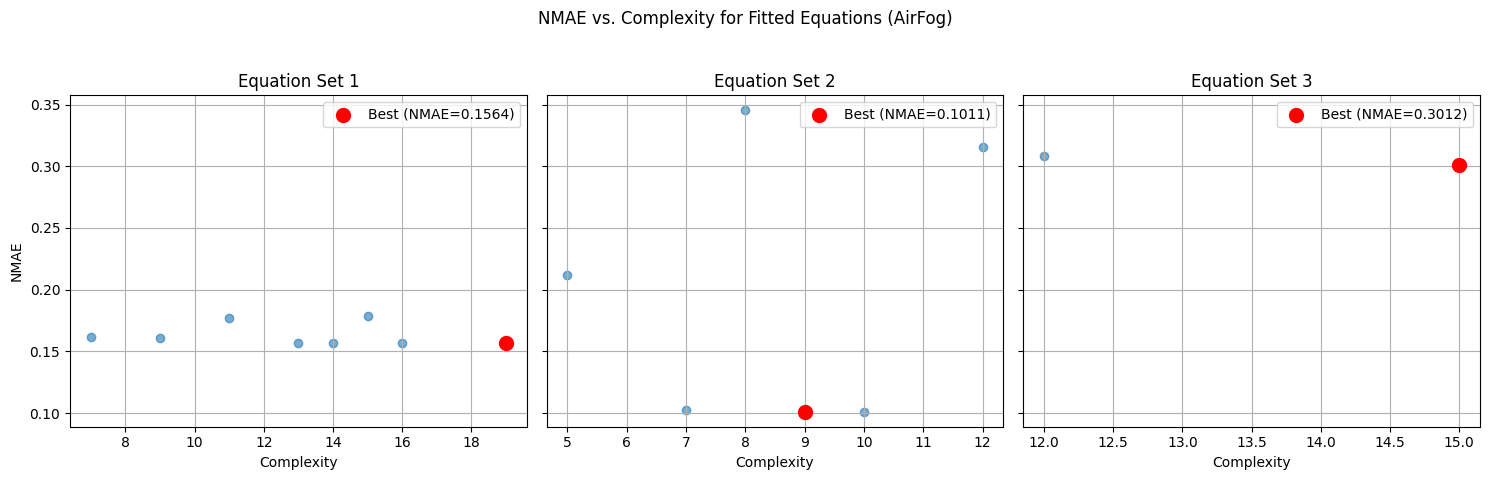

Experiment 1 finished.
Running experiment 2...
Give up equations whose nmae > 0.5: []
Give up equations whose nmae > 0.5: [{'equation': 'x1*x2-c[0]*log(x3+1)', 'complexity': 10, 'nmae': np.float64(6.26443084151318), 'fitted_params': [10.0]}]
Give up equations whose nmae > 0.5: [{'equation': '1/(1+exp(-(x1*x2-c[0]*log(x3+1))))', 'complexity': 17, 'nmae': np.float64(0.5947259737588412), 'fitted_params': [-4.999999420388819]}, {'equation': 'min(1,max(0,x1*x2/(x3+c[0])))', 'complexity': 7, 'nmae': np.float64(0.8067799763488044), 'fitted_params': [0.10811873941750427]}]


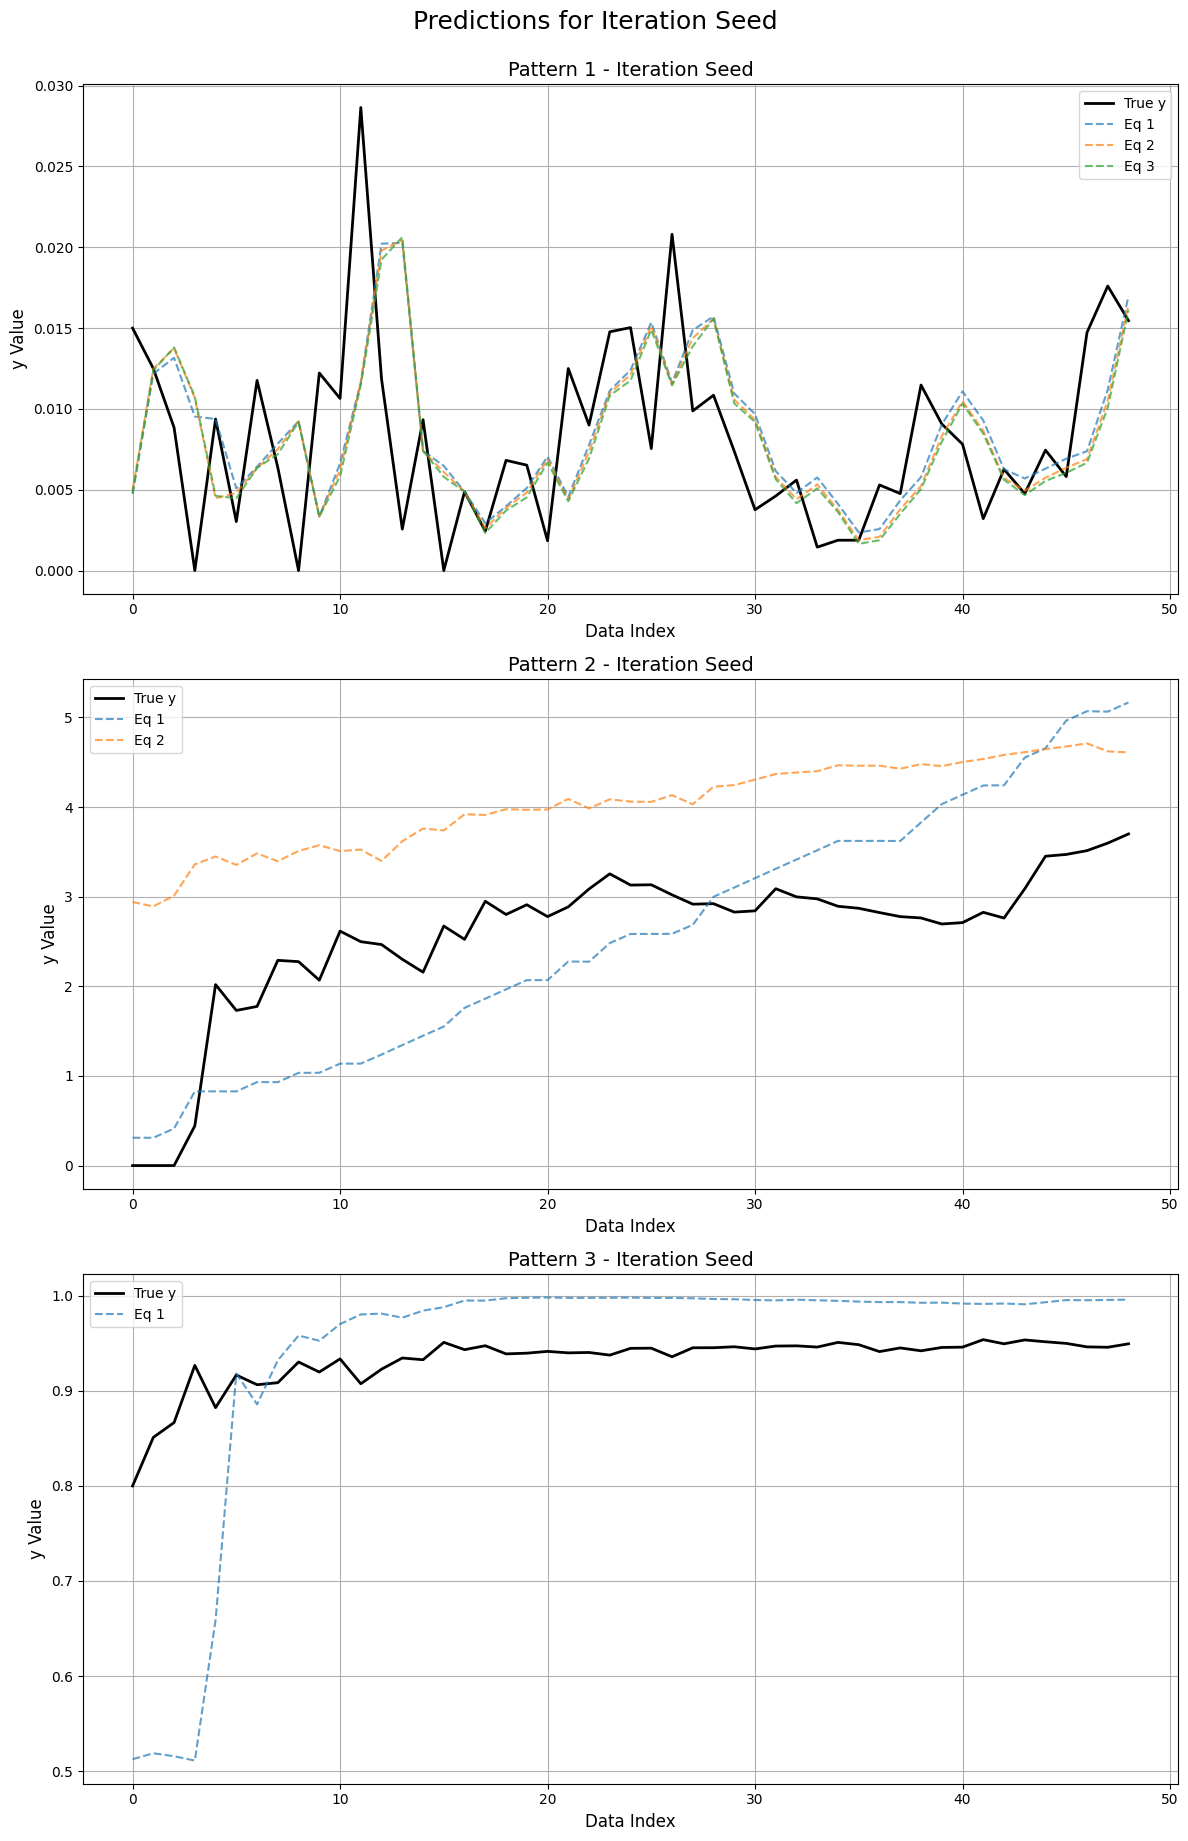

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

Pattern 1:
We are predicting compute load at time t+1 based on current values and past values. This is a temporal sequence modeling task.
x4 and x5 are state variables (current and previous load). Including terms like x4, x5, and (x4 - x5) will capture memory/dynamics.
x1 (task success ratio) is expected to be inversely related to the load (if success is high, fewer retries → less load), but this may depend on system behavior.
x2 (vehicle density) and x3 (V2U density) are infrastructural indicators — more vehicles and more V2U links may increase load due to more tasks initiated.
I should try combinations like x2 / x4, x1 * x3, and log(x4 + 1), as well as moving averages or differences.
Try residuals like x4 - x5, x2 * x3, polynomial and interaction terms.

Pattern 2:
Predicting V2U rate at next time step from vehicle density, UAV density, and compute load.
x1 is vehicle density, x2 is UAV density, x

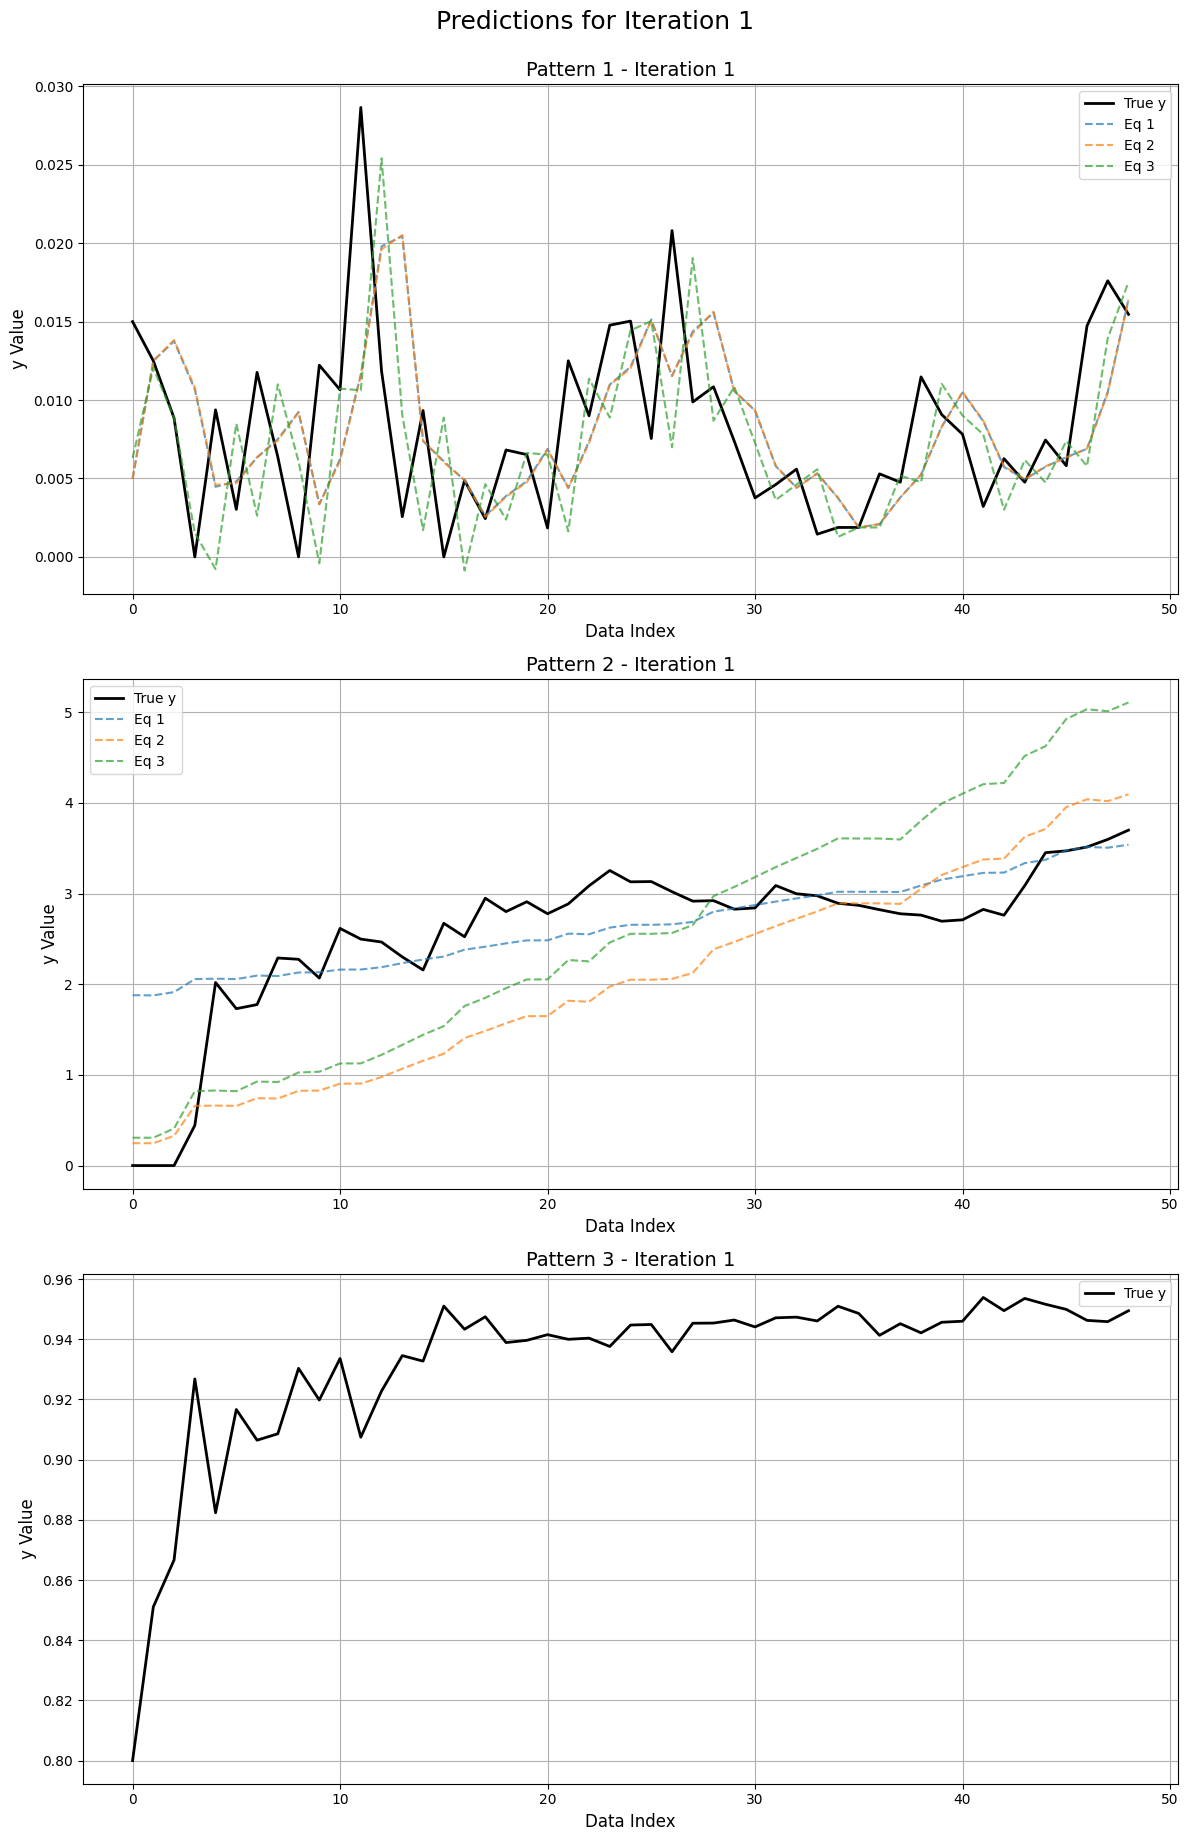

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x2/(x3+c[1]))-c[2]*(x4-x5)**2', 'complexity': 17, 'nmae': np.float64(0.1699031008039232), 'fitted_params': [1.0505574832286868e-06, -0.00016834756410233354, 9.999984955291609]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970959343616), 'fitted_params': [-0.5226465566843941]}, {'equation': 'x4-c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021775876998), 'fitted_params': [0.5087400683851977, 0.00012130388720890591]}, {'equation': 'x4+c[0]*(x1*x3)-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468564536893), 'fitted_params': [7.813348361080537e-05, 0.5013737043385947]}, {'equation': 'x4+c[0]*x2/(x3+c[1])-c[2]*(x4-x5)', 'complexity': 15, 'nmae': np.float64(0.1529456022542684), 'fitted_params': [0.00034398767274979936, -0.36518318118269655, 0.48357043318380505]}], [{'equation': 'x1*x2/(x3+c[0])', 'complexity': 7, 'nmae': np.float64(0.23955959631

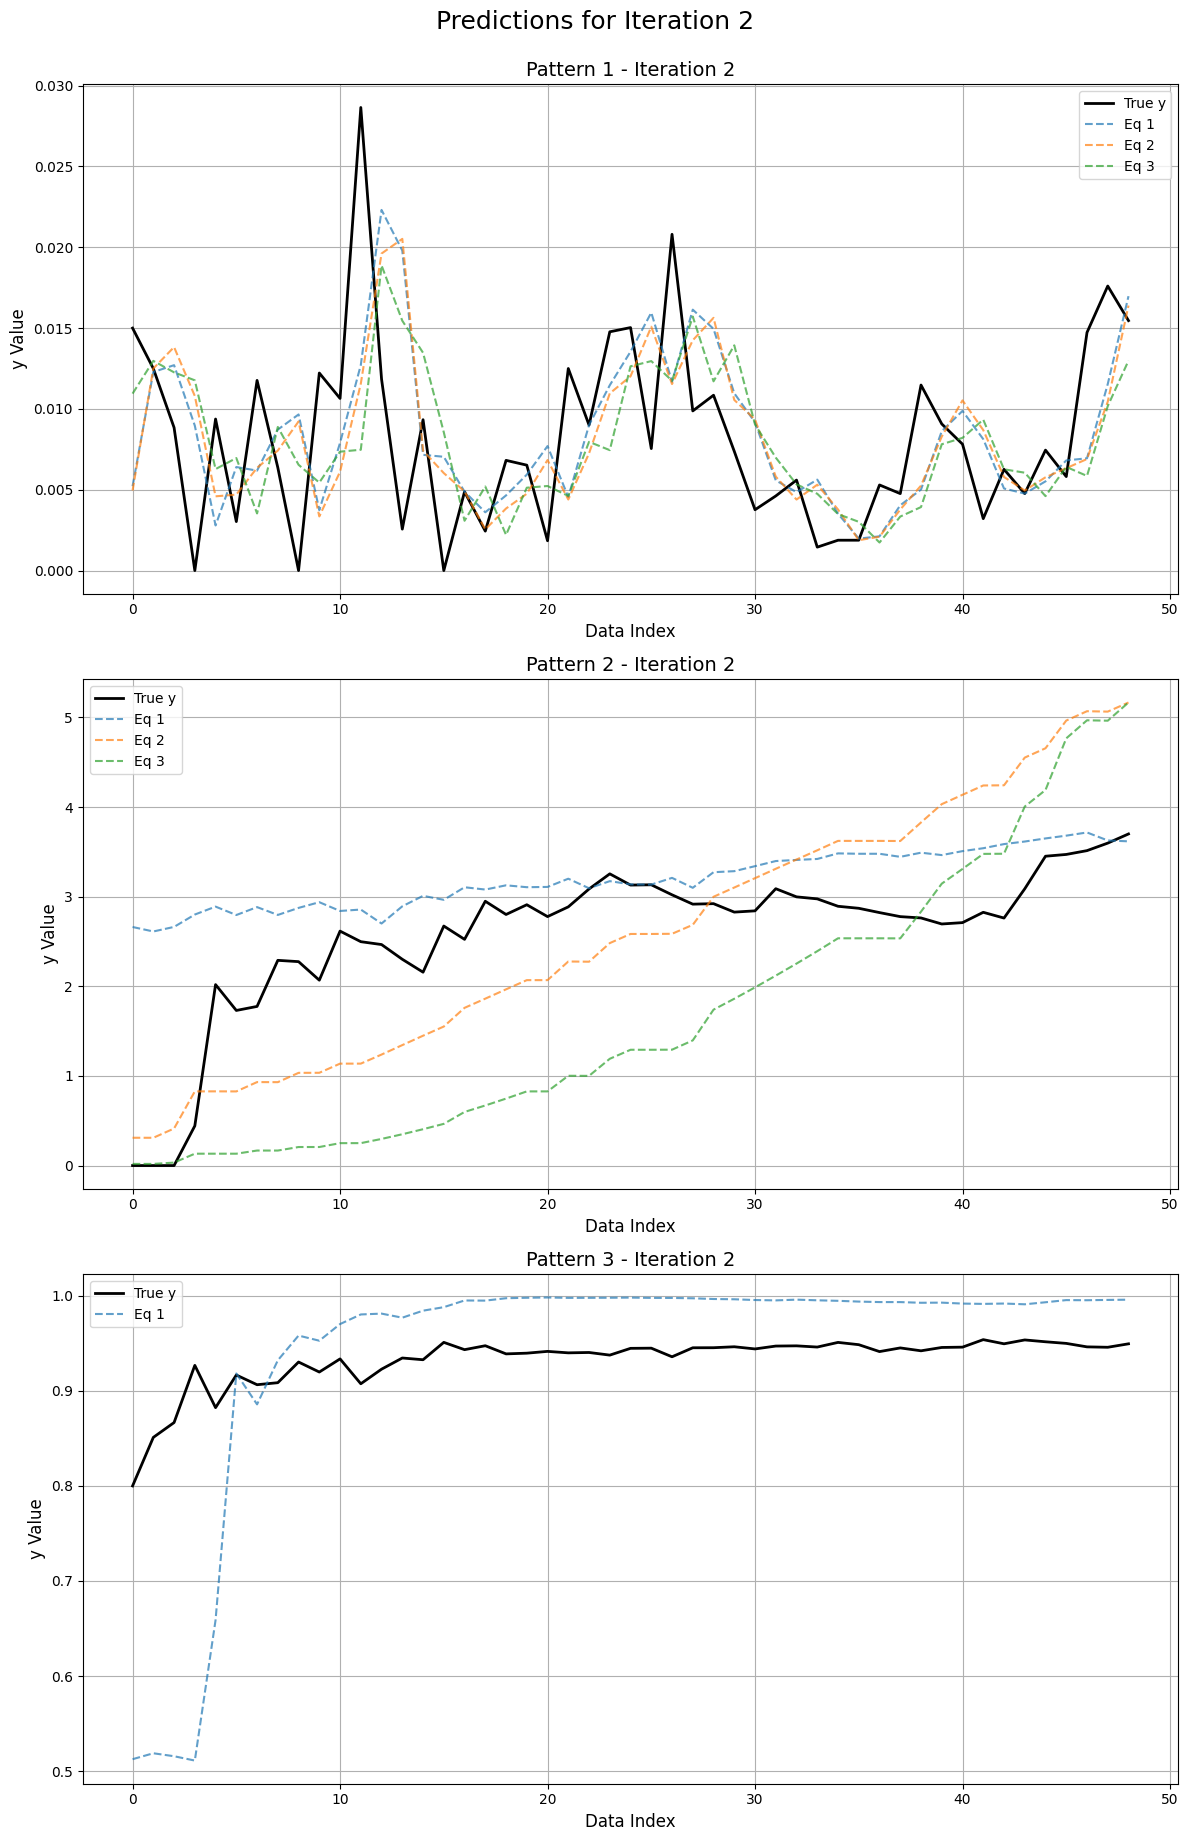

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x2/(x3+c[1]))-c[2]*(x4-x5)**2', 'complexity': 17, 'nmae': np.float64(0.1699031008039232), 'fitted_params': [1.0505574832286868e-06, -0.00016834756410233354, 9.999984955291609]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970959343616), 'fitted_params': [-0.5226465566843941]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021584430502), 'fitted_params': [-0.5087186201433567, 0.0001212987262400618]}, {'equation': 'x4+c[0]*(x1*x3)-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468564536893), 'fitted_params': [7.813348361080537e-05, 0.5013737043385947]}, {'equation': 'x4+c[0]*x1*x3-c[1]*(x4-x5)+c[2]*log(x2+1)', 'complexity': 20, 'nmae': np.float64(0.15584129123657317), 'fitted_params': [0.0012867883165257332, 0.41298106761320064, -0.001815350316983766]}, {'equation': 'x4+c[0]*x2/(x3+c[1])-c[2]*(x4-x5)', 'complexity': 15, 'nmae'

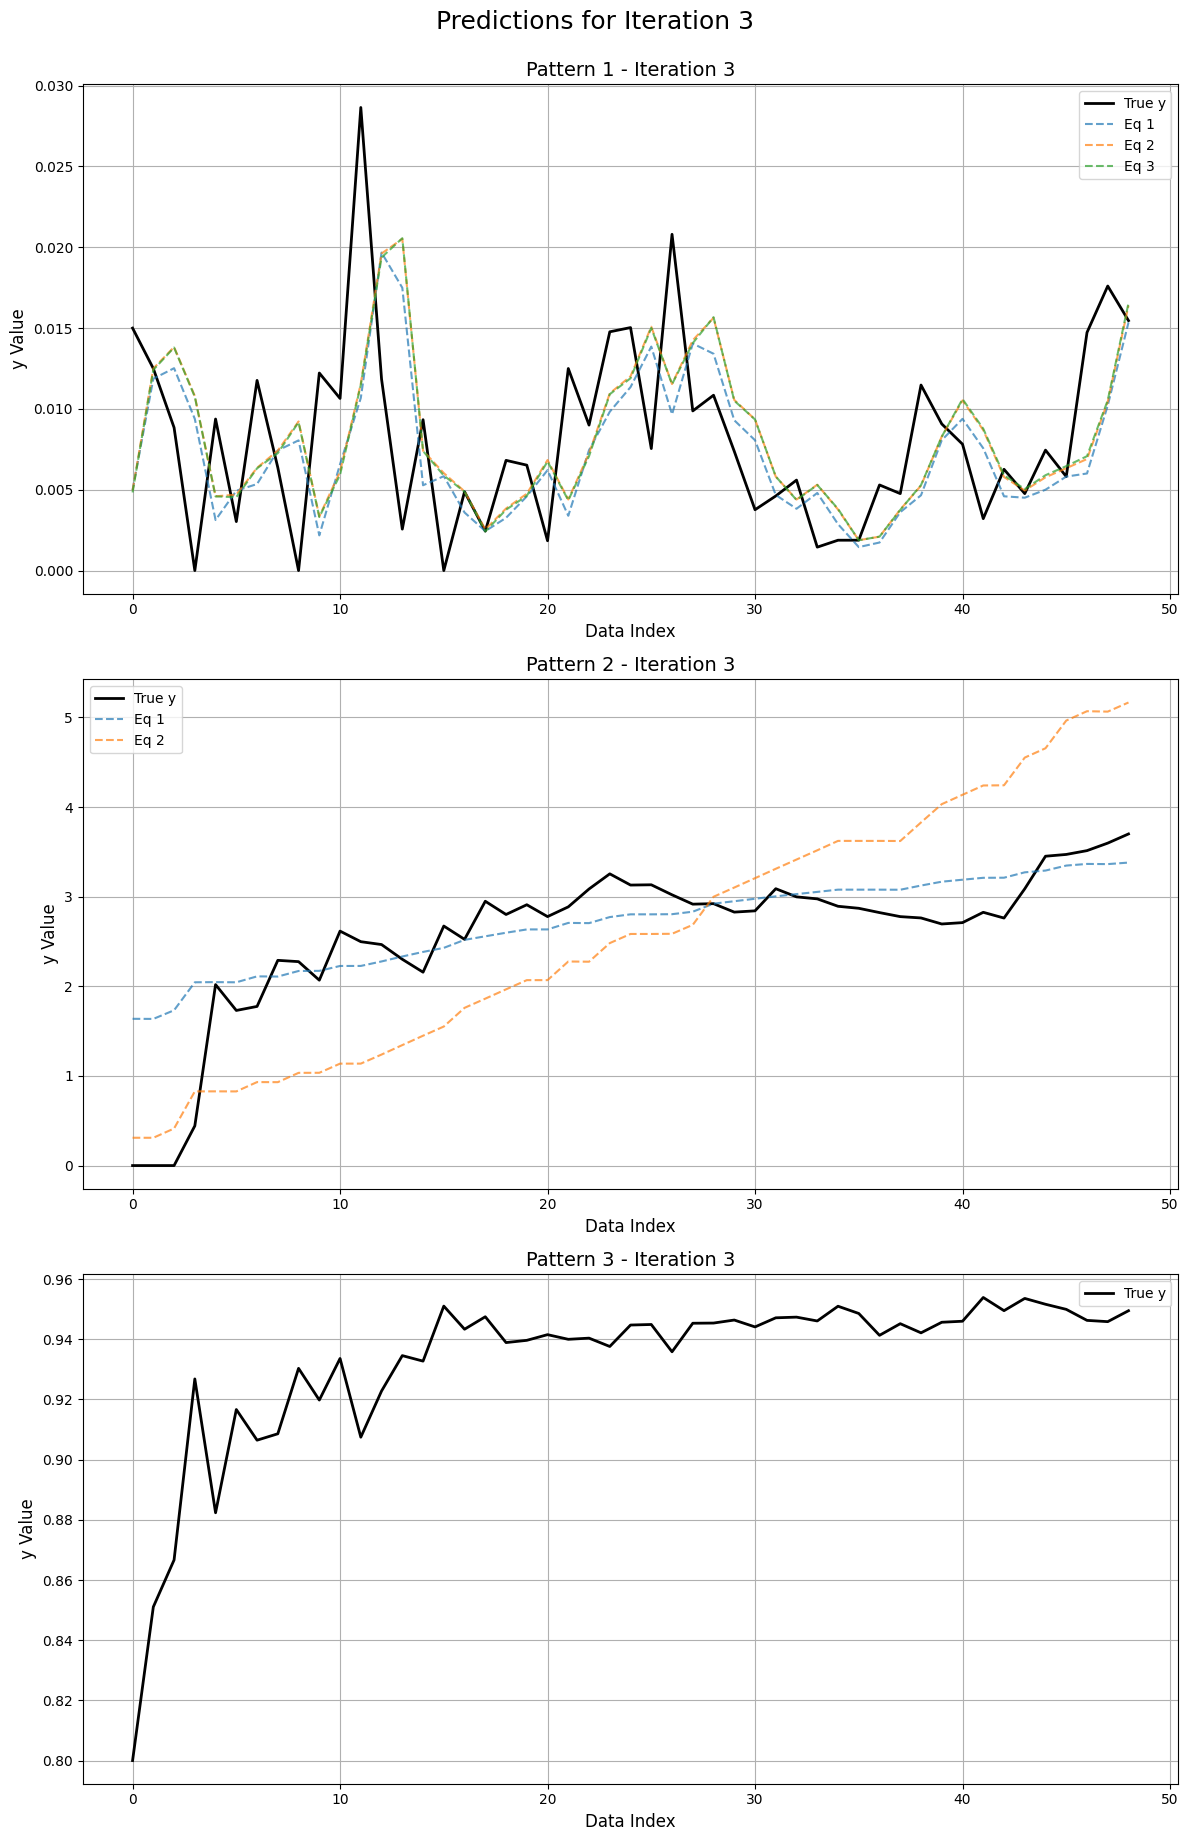

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970959343616), 'fitted_params': [-0.5226465566843941]}, {'equation': 'x4+c[0]*(x2**2)/(x3+c[1])-c[2]*(x4-x5)', 'complexity': 17, 'nmae': np.float64(0.1565042714942396), 'fitted_params': [0.0001122305080944478, 9.950363735942444, 0.5169474238453837]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021584430502), 'fitted_params': [-0.5087186201433567, 0.0001212987262400618]}, {'equation': 'x4+c[0]*(x1*x3)-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468564536893), 'fitted_params': [7.813348361080537e-05, 0.5013737043385947]}, {'equation': 'x4+c[0]*x1*x3-c[1]*(x4-x5)+c[2]*log(x2+1)', 'complexity': 20, 'nmae': np.float64(0.15584129123657317), 'fitted_params': [0.0012867883165257332, 0.41298106761320064, -0.001815350316983766]}, {'equation': 'x4+c[0]*movavg(4, 3)-c[1]*(x4-x5)', 'complexity': 11, 'nmae': np.f

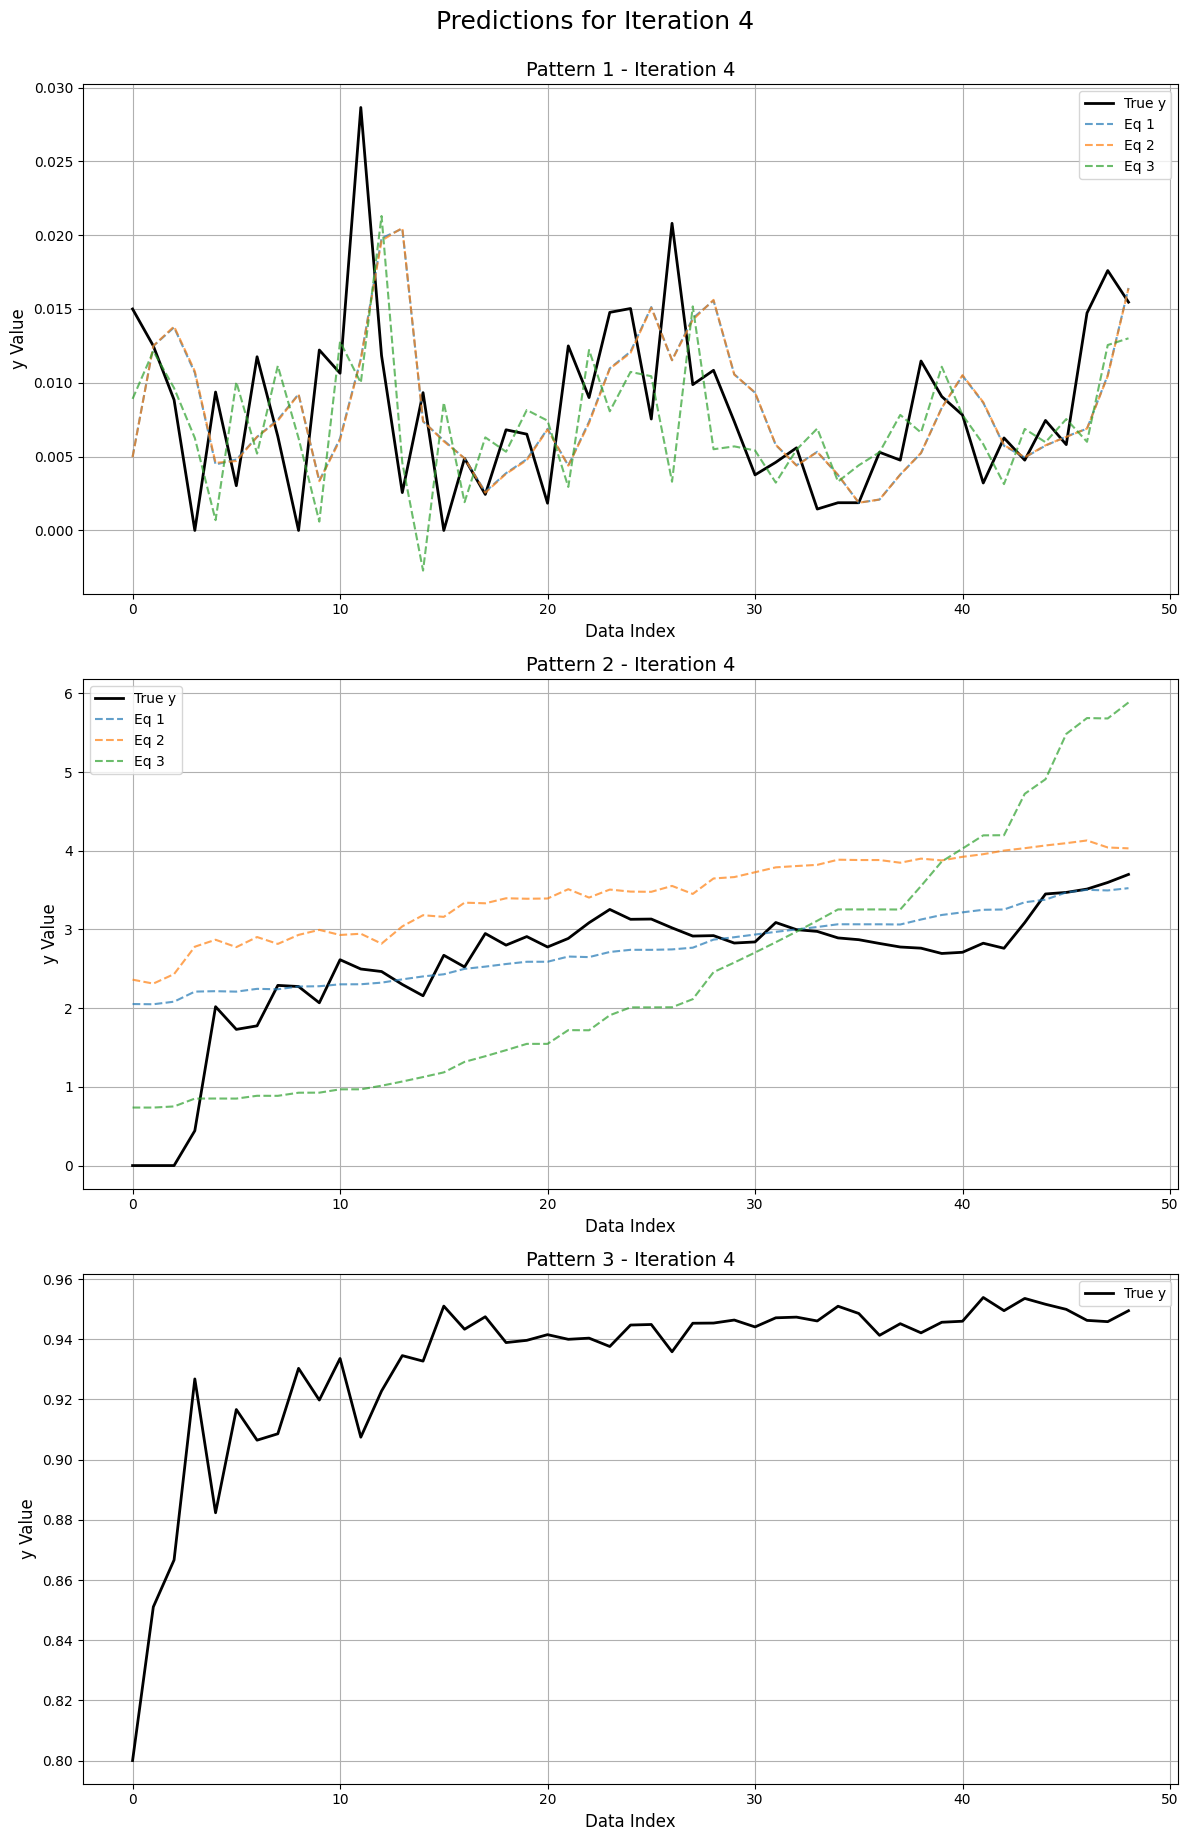

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970959343616), 'fitted_params': [-0.5226465566843941]}, {'equation': 'x4+c[0]*(x2**2)/(x3+c[1])-c[2]*(x4-x5)', 'complexity': 17, 'nmae': np.float64(0.1565042714942396), 'fitted_params': [0.0001122305080944478, 9.950363735942444, 0.5169474238453837]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021584430502), 'fitted_params': [-0.5087186201433567, 0.0001212987262400618]}, {'equation': 'x4+c[0]*log(x2+1)*x1-c[1]*(x4-x5)', 'complexity': 16, 'nmae': np.float64(0.1564921801994998), 'fitted_params': [0.00012721352712337649, 0.5073815701155021]}, {'equation': 'x4+c[0]*(x1*x3)-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468564536893), 'fitted_params': [7.813348361080537e-05, 0.5013737043385947]}, {'equation': 'x4+c[0]*x1*x3-c[1]*(x4-x5)+c[2]*log(x2+1)', 'complexity': 20, 'nmae': np.float64(0.155841291236573

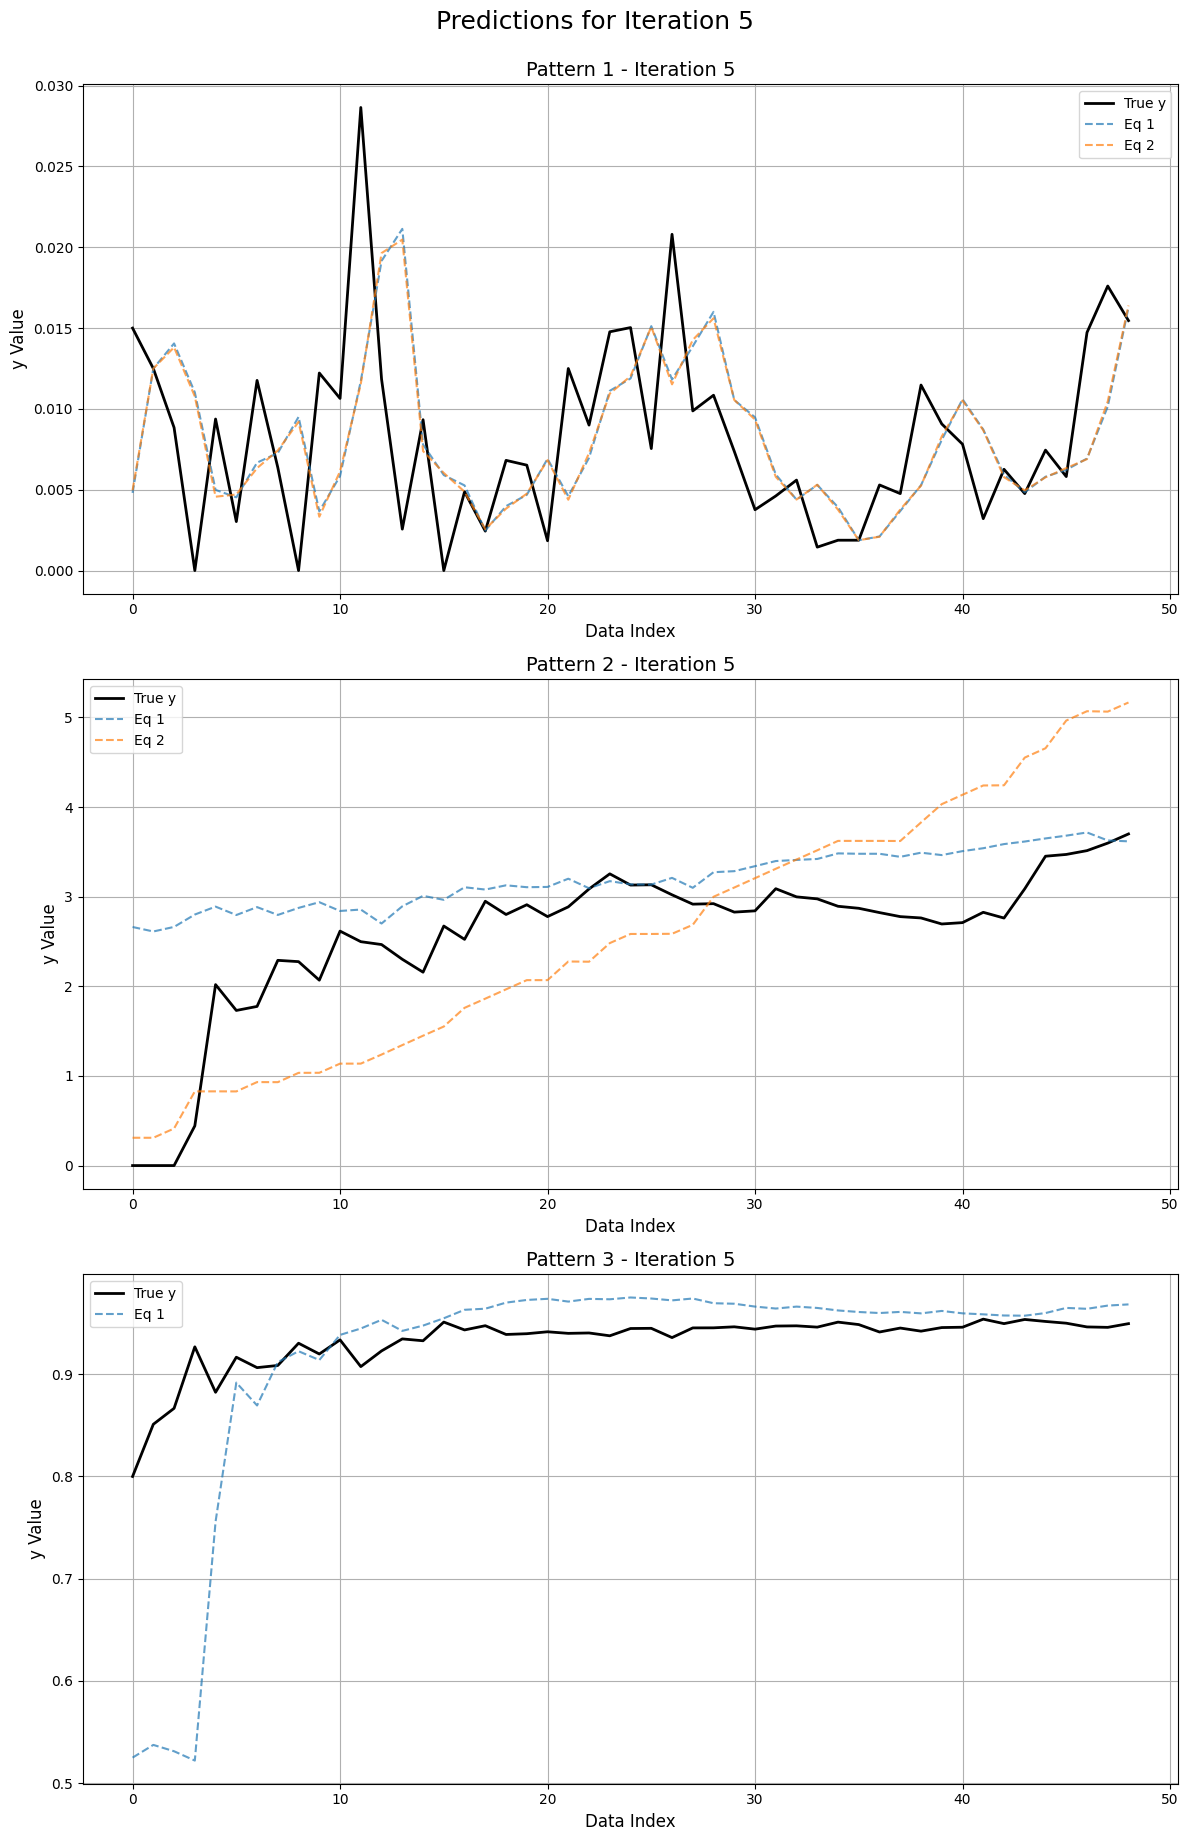

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970959343616), 'fitted_params': [-0.5226465566843941]}, {'equation': 'x4+c[0]*(x2**2)/(x3+c[1])-c[2]*(x4-x5)', 'complexity': 17, 'nmae': np.float64(0.1565042714942396), 'fitted_params': [0.0001122305080944478, 9.950363735942444, 0.5169474238453837]}, {'equation': 'x4+c[0]*(x4-x5)+c[1]*log(x2+1)', 'complexity': 14, 'nmae': np.float64(0.1565021584430502), 'fitted_params': [-0.5087186201433567, 0.0001212987262400618]}, {'equation': 'x4+c[0]*log(x2+1)*x1-c[1]*(x4-x5)', 'complexity': 16, 'nmae': np.float64(0.1564921801994998), 'fitted_params': [0.00012721352712337649, 0.5073815701155021]}, {'equation': 'x4+c[0]*(x1**2)*log(x2+1)-c[1]*(x4-x5)', 'complexity': 18, 'nmae': np.float64(0.15648304892101833), 'fitted_params': [0.000133574330046722, 0.5066339388104206]}, {'equation': 'x4+c[0]*(x1*x3)-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468564536893),

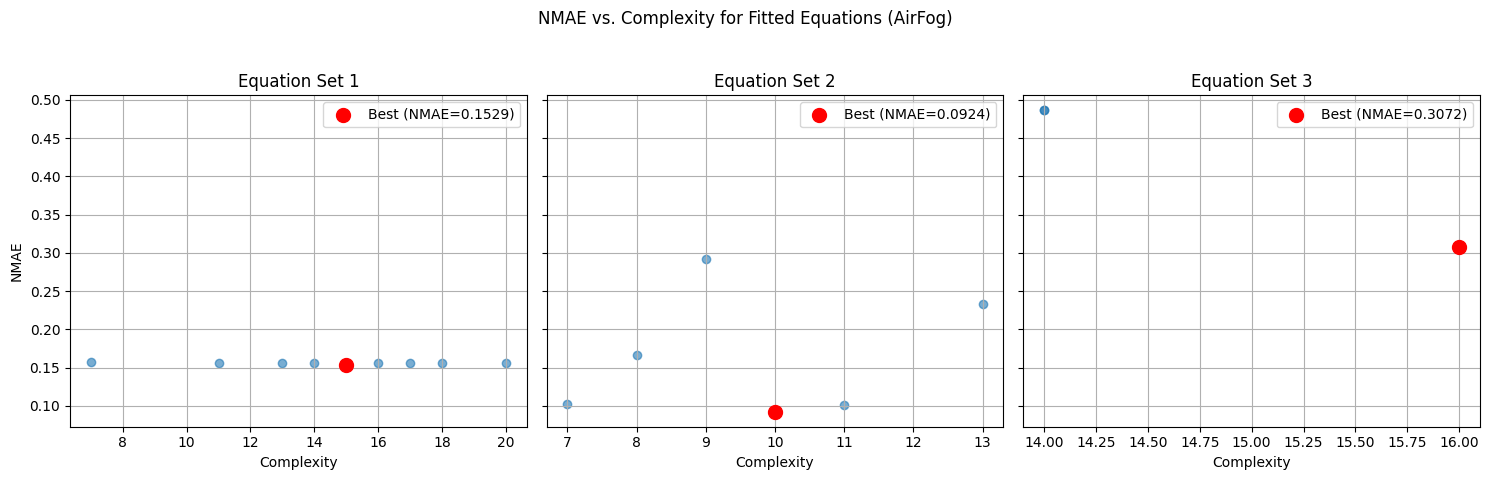

Experiment 2 finished.
Running experiment 3...
Give up equations whose nmae > 0.5: []
Give up equations whose nmae > 0.5: []
Give up equations whose nmae > 0.5: [{'equation': '1/(1+exp(c[0]*x3-c[1]*x1*x2))', 'complexity': 14, 'nmae': np.float64(0.5526863571734346), 'fitted_params': [-4.999996911382692, 4.301870941655448]}, {'equation': 'x1*x2/(x3+c[0])', 'complexity': 7, 'nmae': np.float64(2.141995477668602), 'fitted_params': [7.411568184337433]}]


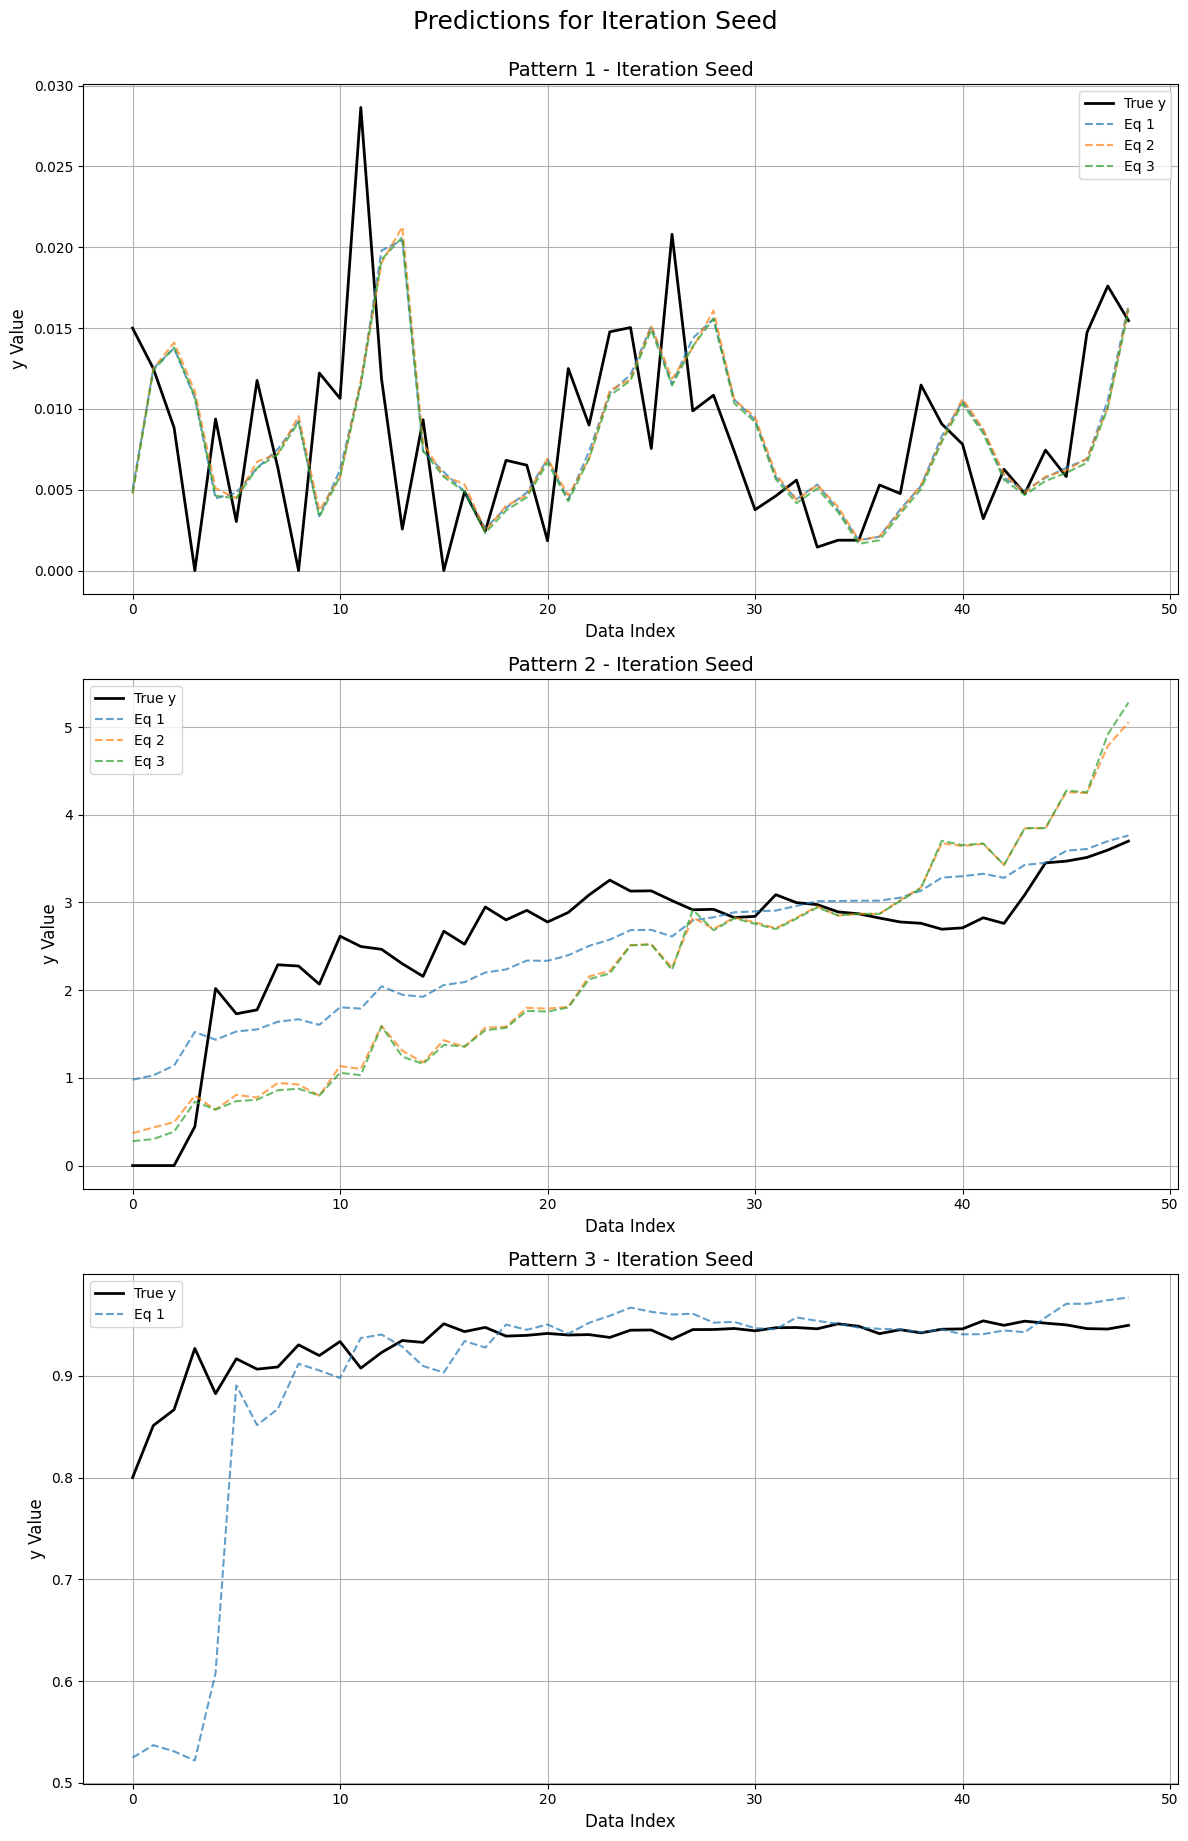

Iteration:Seed
SciPy feedback used for this iteration:
None
LLM thoughts:
Scratch Pad:

Pattern 1:
- y is the future average compute load.
- Variables include task success ratio (x1), vehicle density (x2), V2U density (x3), current compute load (x4), and previous compute load (x5).
- The output y has a low range (0–0.03) and fluctuates sharply, possibly due to residual dynamics and congestion effects.
- Expressions should capture oscillation, memory, and interaction effects.
- Candidate terms: (x4 - x5), x1 * x3, x2 / (x4 + c), x3², log(x4 + 1), moving average of x1.

Pattern 2:
- y is the V2U rate (dependent on vehicle and UAV density and compute load).
- V2U rate increases rapidly with x1, then saturates; possibly logarithmic or square root.
- x2 is constant (7.194), so it may act as a scaling factor.
- x3 (compute load) negatively impacts y.
- Candidate terms: sqrt(x1), x1 / (x3 + c), x1 - x3, x1² / (x3 + c).

Pattern 3:
- y is the task success ratio bounded between [0, 1].
- Sensit

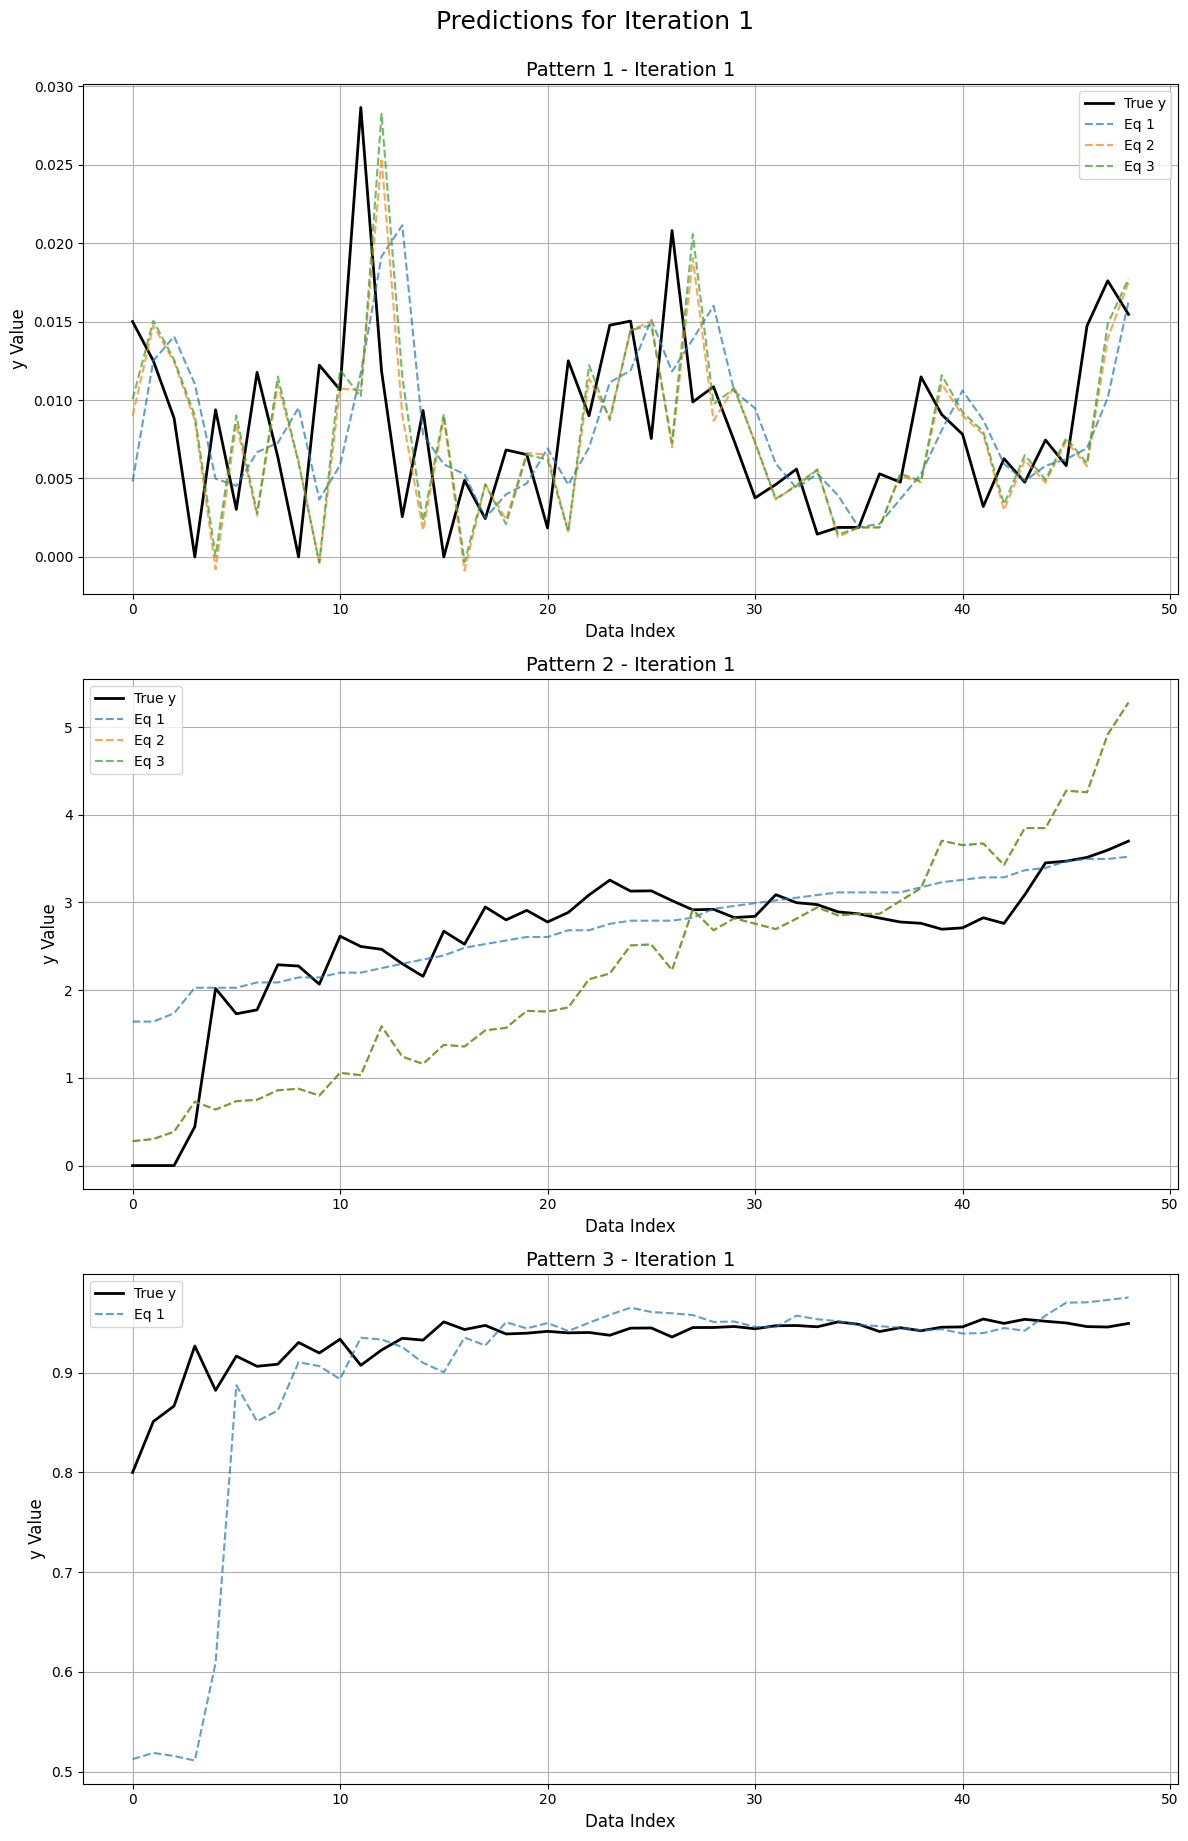

Iteration:1
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x4-x5)**2', 'complexity': 9, 'nmae': np.float64(0.17694692143709323), 'fitted_params': [-10.0]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970893197427), 'fitted_params': [-0.5226472756284786]}, {'equation': 'x4+c[0]*movavg(1, 3)+c[1]*(x4-x5)', 'complexity': 11, 'nmae': np.float64(0.156466147234924), 'fitted_params': [0.00024402613759466618, -0.5399087653261758]}, {'equation': 'x4+c[0]*movavg(1, 3)-c[1]*x3+c[2]*(x4-x5)', 'complexity': 15, 'nmae': np.float64(0.15646597074936064), 'fitted_params': [0.00028720844694801674, 1.3094576300500418e-05, -0.5469141506155485]}, {'equation': 'x4+c[0]*x1*x3-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468831302187), 'fitted_params': [7.813170318869529e-05, 0.501395457338531]}], [{'equation': 'c[0]*x1*x2/(x3+c[1])', 'complexity': 9, 'nmae': np.float64(0.20875086110597368), 'fitted_params': [-0.005576062887813757, -0.072256920076

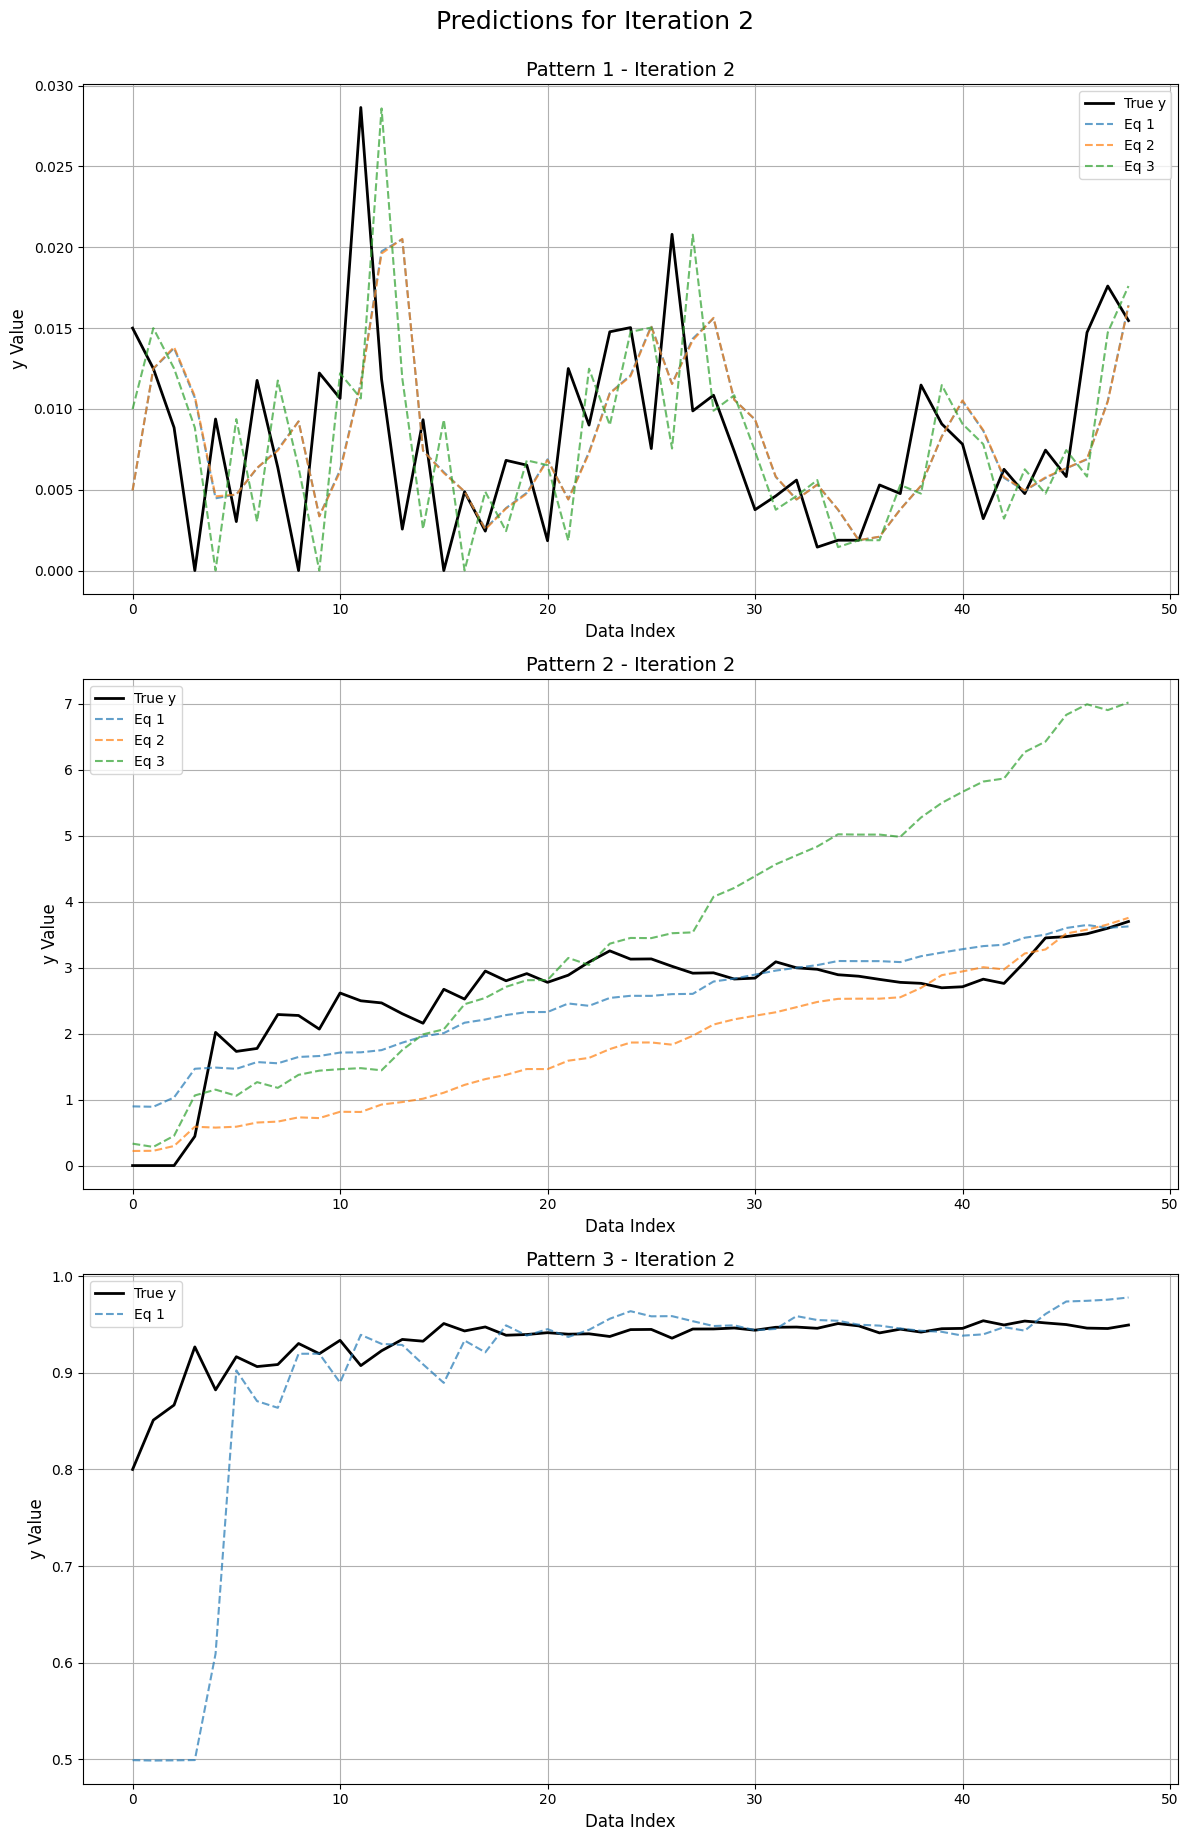

Iteration:2
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*(x4-x5)**2', 'complexity': 9, 'nmae': np.float64(0.17694692143709323), 'fitted_params': [-10.0]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970893197427), 'fitted_params': [-0.5226472756284786]}, {'equation': 'x4+c[0]*log(x2+1)+c[1]*(x4-x5)', 'complexity': 14, 'nmae': np.float64(0.15650215468600193), 'fitted_params': [0.00012129618976887464, -0.5087133173950232]}, {'equation': 'x4+c[0]*movavg(1, 3)+c[1]*(x4-x5)', 'complexity': 11, 'nmae': np.float64(0.156466147234924), 'fitted_params': [0.00024402613759466618, -0.5399087653261758]}, {'equation': 'x4+c[0]*movavg(1, 3)-c[1]*x3+c[2]*(x4-x5)', 'complexity': 15, 'nmae': np.float64(0.15646597074936064), 'fitted_params': [0.00028720844694801674, 1.3094576300500418e-05, -0.5469141506155485]}, {'equation': 'x4+c[0]*x1*x3-c[1]*(x4-x5)', 'complexity': 13, 'nmae': np.float64(0.15645468831302187), 'fitted_params': [7.813170318869529e-05, 0.5

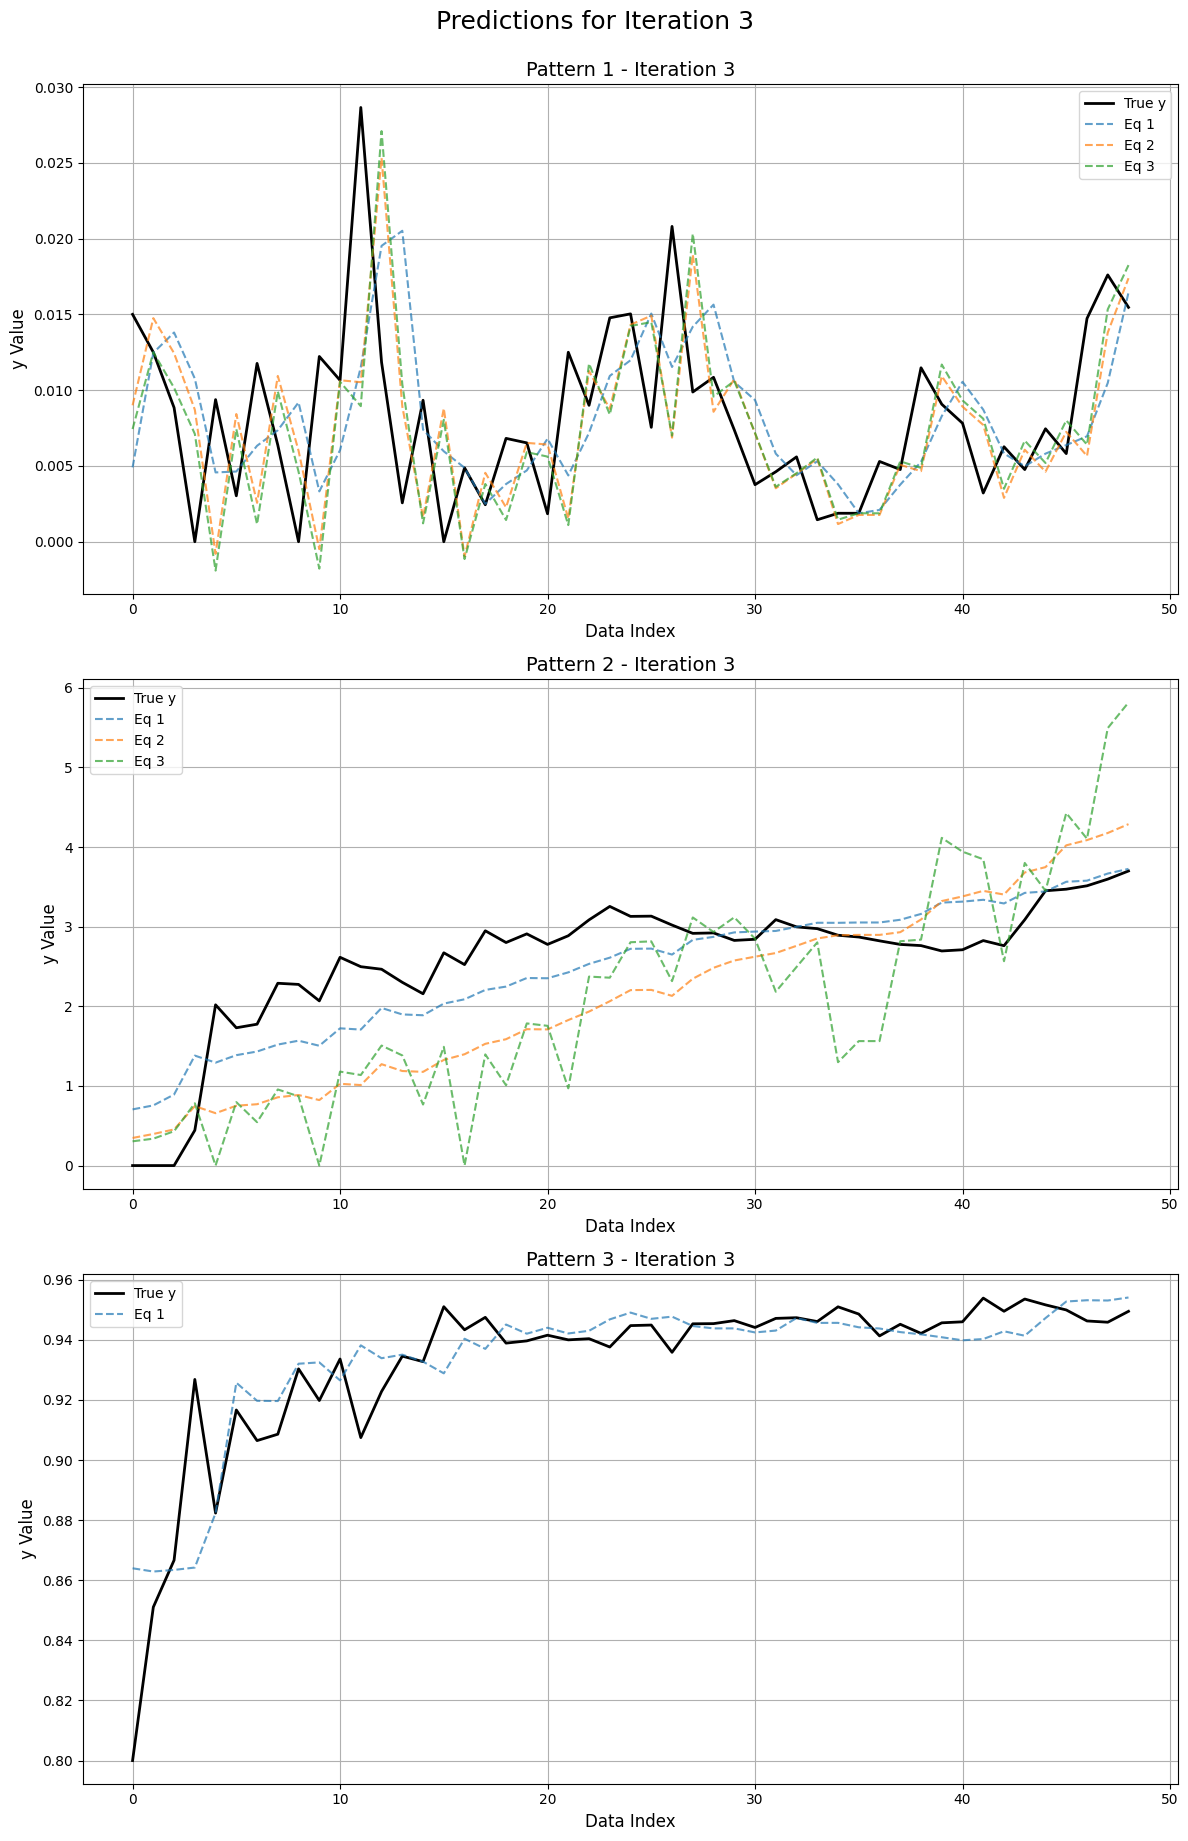

Iteration:3
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*movavg(1, 3)+c[1]*log(x2+1)', 'complexity': 12, 'nmae': np.float64(0.17792161968388714), 'fitted_params': [-0.003984549924818734, 0.002101568612768712]}, {'equation': 'x4+c[0]*(x4-x5)**2', 'complexity': 9, 'nmae': np.float64(0.17694692143709323), 'fitted_params': [-10.0]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970893197427), 'fitted_params': [-0.5226472756284786]}, {'equation': 'x4+c[0]*log(x2+1)+c[1]*(x4-x5)', 'complexity': 14, 'nmae': np.float64(0.15650215468600193), 'fitted_params': [0.00012129618976887464, -0.5087133173950232]}, {'equation': 'x4+c[0]*movavg(1, 3)+c[1]*(x4-x5)', 'complexity': 11, 'nmae': np.float64(0.156466147234924), 'fitted_params': [0.00024402613759466618, -0.5399087653261758]}, {'equation': 'x4+c[0]*movavg(1, 3)-c[1]*x3+c[2]*(x4-x5)', 'complexity': 15, 'nmae': np.float64(0.15646597074936064), 'fitted_params': [0.00028720844694801674, 1.309457630050041

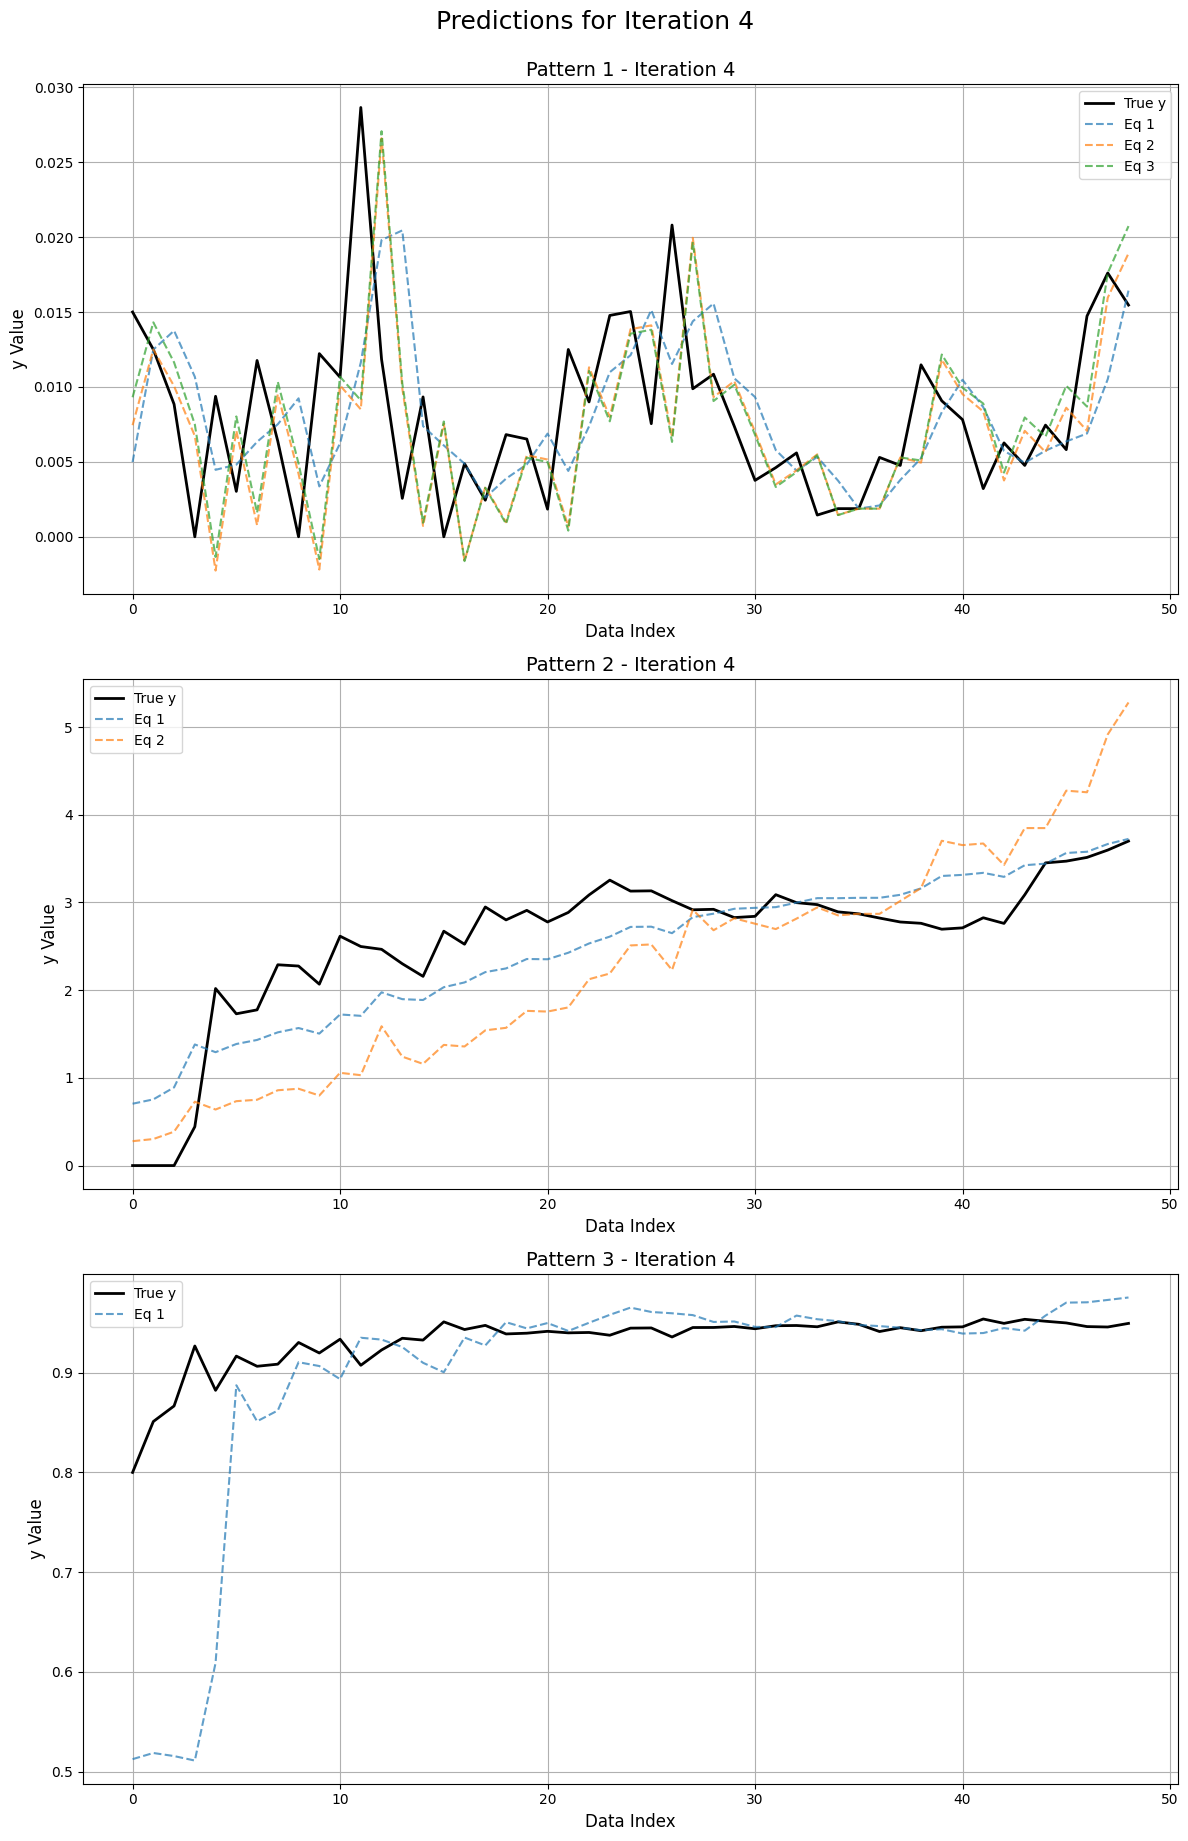

Iteration:4
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*movavg(1, 3)+c[1]*log(x2+1)', 'complexity': 12, 'nmae': np.float64(0.17792161968388714), 'fitted_params': [-0.003984549924818734, 0.002101568612768712]}, {'equation': 'x4+c[0]*(x4-x5)**2', 'complexity': 9, 'nmae': np.float64(0.17694692143709323), 'fitted_params': [-10.0]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970893197427), 'fitted_params': [-0.5226472756284786]}, {'equation': 'x4+c[0]*log(x2+1)+c[1]*(x4-x5)', 'complexity': 14, 'nmae': np.float64(0.15650215468600193), 'fitted_params': [0.00012129618976887464, -0.5087133173950232]}, {'equation': 'x4+c[0]*movavg(1, 3)+c[1]*(x4-x5)', 'complexity': 11, 'nmae': np.float64(0.156466147234924), 'fitted_params': [0.00024402613759466618, -0.5399087653261758]}, {'equation': 'x4+c[0]*movavg(1, 3)-c[1]*x3+c[2]*(x4-x5)', 'complexity': 15, 'nmae': np.float64(0.15646597074936064), 'fitted_params': [0.00028720844694801674, 1.309457630050041

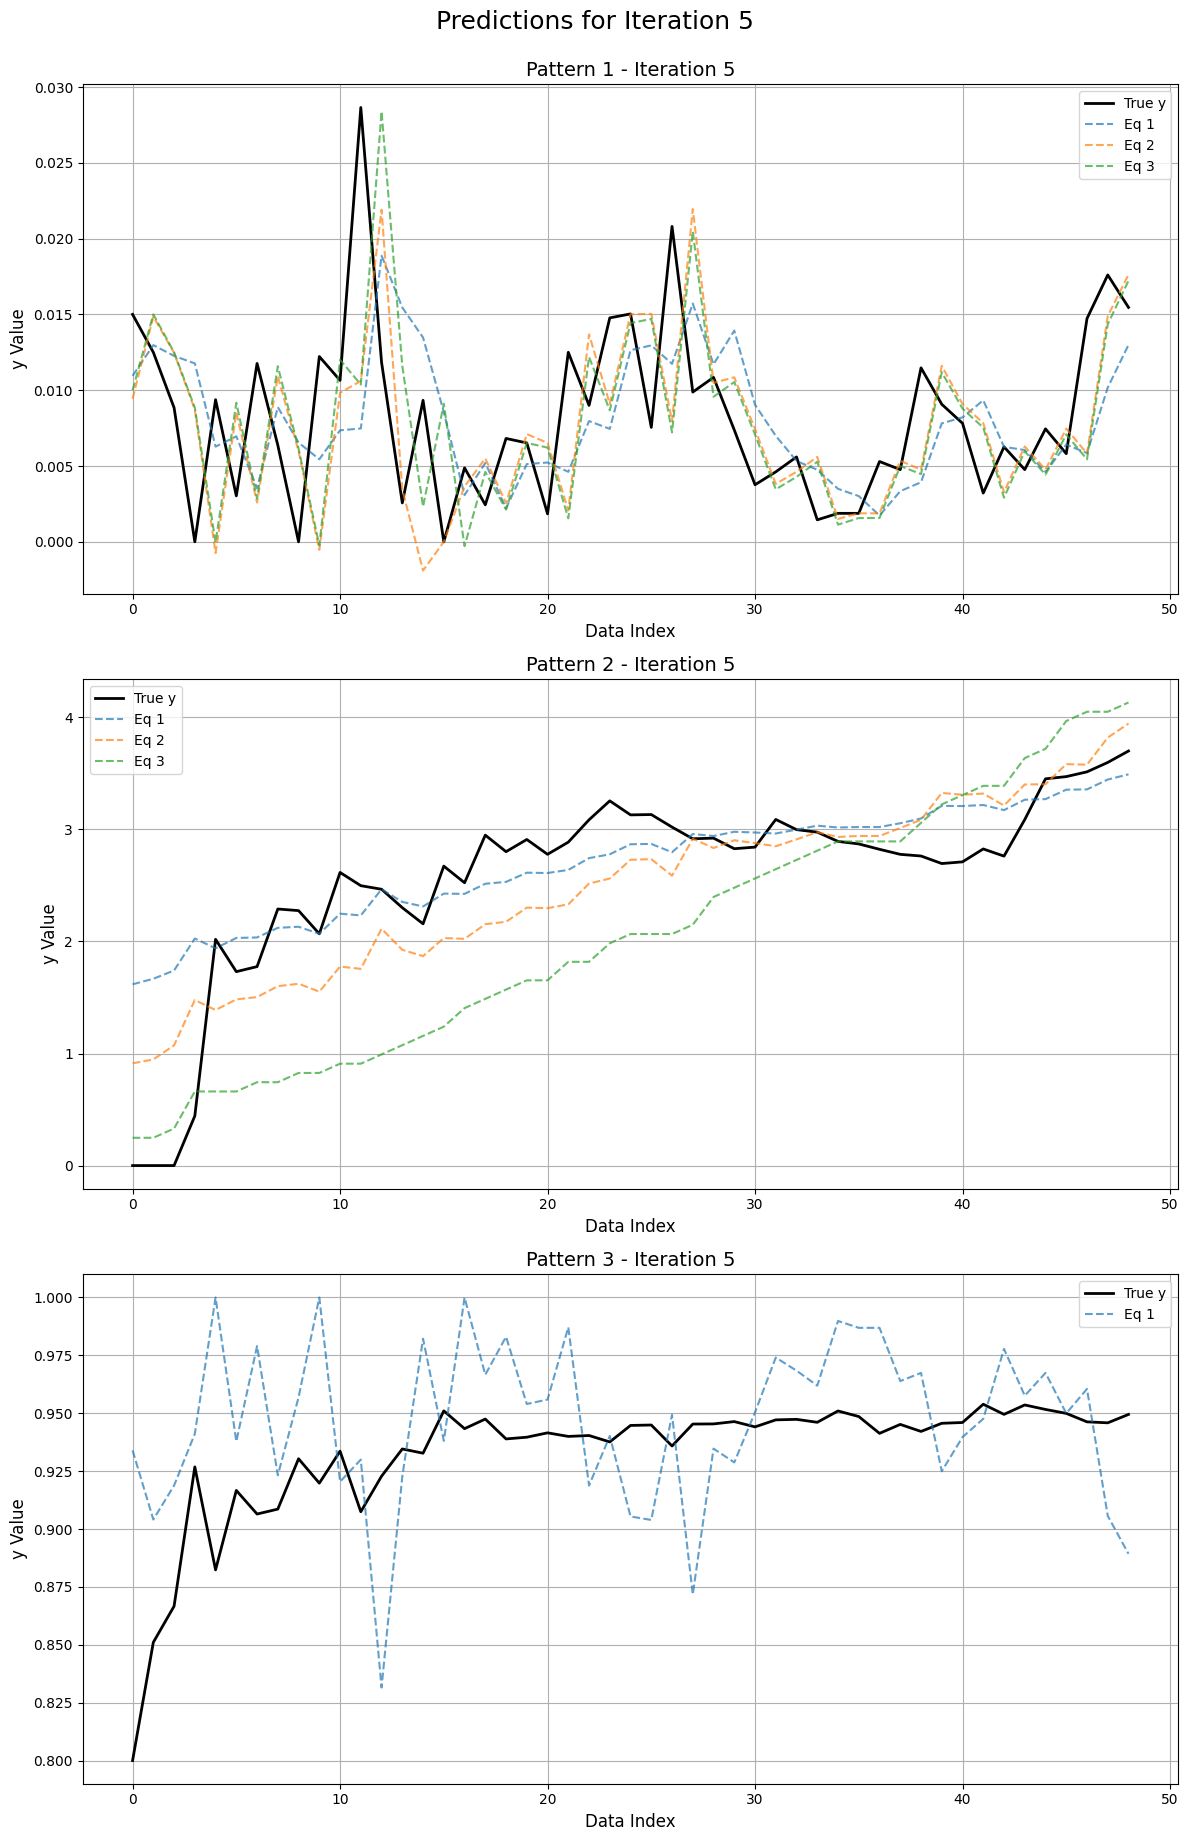

Iteration:5
SciPy feedback used for this iteration:
[[{'equation': 'x4+c[0]*movavg(1, 3)+c[1]*log(x2+1)', 'complexity': 12, 'nmae': np.float64(0.17792161968388714), 'fitted_params': [-0.003984549924818734, 0.002101568612768712]}, {'equation': 'x4+c[0]*(x4-x5)**2', 'complexity': 9, 'nmae': np.float64(0.17694692143709323), 'fitted_params': [-10.0]}, {'equation': 'x4+c[0]*(x4-x5)', 'complexity': 7, 'nmae': np.float64(0.15689970893197427), 'fitted_params': [-0.5226472756284786]}, {'equation': 'x4+c[0]*log(x2+1)+c[1]*(x4-x5)', 'complexity': 14, 'nmae': np.float64(0.15650215468600193), 'fitted_params': [0.00012129618976887464, -0.5087133173950232]}, {'equation': 'x4+c[0]*movavg(1, 3)+c[1]*(x4-x5)', 'complexity': 11, 'nmae': np.float64(0.156466147234924), 'fitted_params': [0.00024402613759466618, -0.5399087653261758]}, {'equation': 'x4+c[0]*movavg(1, 3)-c[1]*x3+c[2]*(x4-x5)', 'complexity': 15, 'nmae': np.float64(0.15646597074936064), 'fitted_params': [0.00028720844694801674, 1.309457630050041

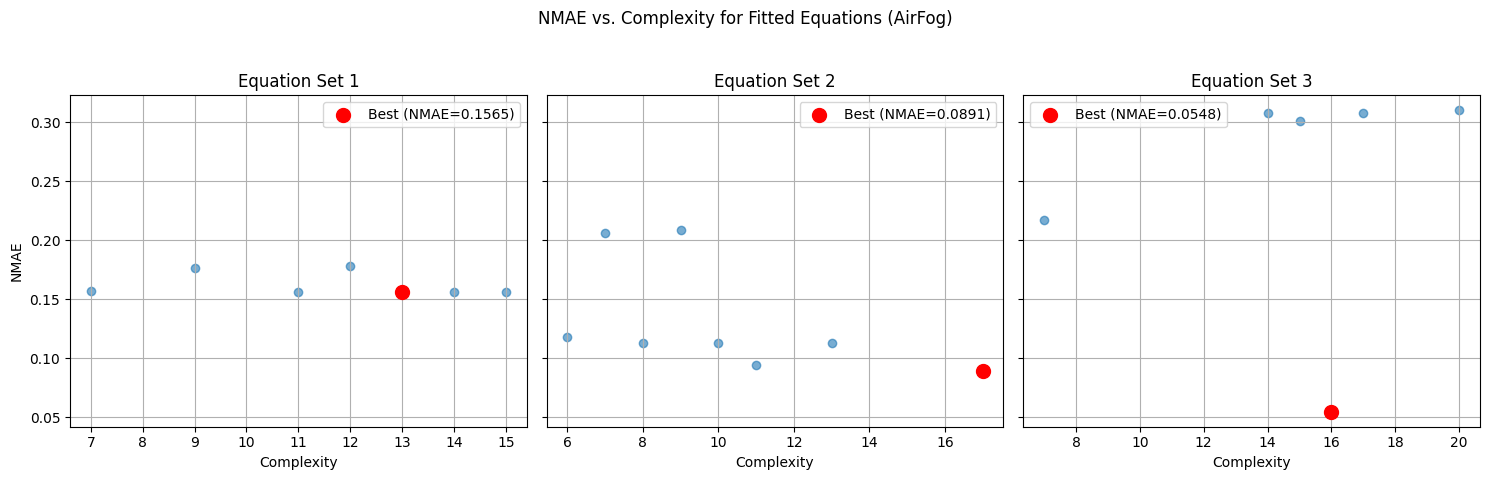

Experiment 3 finished.


In [10]:
import json
#No. of expressions generated in each LLM call
N = 3
temp = 0.7
model = "chatgpt-4o-latest"

#Increase iterations here
total_iterations = 5 

sys_msg= SYS_MSG
ignite_msg = IGNITE
iter_msg = ITER

results_fromAllruns = []
iteration_infos_fromAllruns = []


# Run the experiment n times
for i in range(3):
    print(f"Running experiment {i+1}...")

    # Create a new instance of the experiment class with your settings
    #options = allTools, noContext, noData, noScratchpad
    experiment = airFog(dep_vars, indep_vars, N, temp, context, sys_msg, ignite_msg, iter_msg, model)
    # Run the experiment and store the results
    results, all_expressions, iteration_info, usage_list, total_chain_run_time, all_expressionsLLM = experiment.run(total_iterations)
    
    results_fromAllruns.append({
        'CombResults': results, 
        'all_expressions': all_expressions, 
        'usage_list': usage_list, 
        'total_chain_run_time': total_chain_run_time,
        'LLM raw expressions': all_expressionsLLM
    })
    
    # Store the iteration info
    iteration_infos_fromAllruns.append(iteration_info)

    # print(f"Experiment {i+1} finished. Cost: {experiment.cost()}")
    print(f"Experiment {i+1} finished.")

    directory_path = "results/train"
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)  # This will create all intermediate-level directories needed to contain the leaf directory

    with open(f"{directory_path}/PromptsUsed.txt", 'w') as f:
        f.write(f"##Sytstem Message## {SYS_MSG}\n")
        f.write(f"##Starting Prompt## {IGNITE}\n")
        f.write(f"##Iteration Prompt## {ITER}\n")

    with open(f"{directory_path}/run{i+1}.txt", 'w') as f:
        f.write("Final Results:\n")
        for res in results:
            json.dump(res, f, indent=2)
            f.write("\n")
        # f.write(f"Cost for this run: ${experiment.cost()}\n")
        f.write(f"Total chain run time: {total_chain_run_time} seconds.\n")
        f.write("\n\nIteration Information:\n")
        for info in iteration_info:
            json.dump(info, f, indent=2)
            f.write("\n")

    with open(f"{directory_path}/run{i+1}.json", 'w') as json_file:
        json.dump(results, json_file, indent=2)

In [1]:
from helper import format_and_parse_expression_matrix, format_expressions

llm_ord_output = '[["x_{4} + c_{0}(x_{4} - x_{5})","x_{4}(c_{0} + x_{1})","c_{0}\\\\,\\\\mathrm{movavg}(x_{1},3) + c_{1}x_{5}"],["\\\\min\\\\bigl(c_{0},\\\\frac{x_{2}}{x_{1} + c_{1}}\\\\bigr)","\\\\frac{x_{1}x_{2}}{c_{0} + x_{3}}","\\\\frac{1}{1 + \\\\exp\\\\bigl(-c_{0}(x_{2}/x_{1})\\\\bigr)}"],["\\\\frac{1}{1 + \\\\exp\\\\bigl(-c_{0}(x_{1}x_{2})\\\\bigr)}","\\\\frac{1}{1 + \\\\exp\\\\bigl(-(x_{1} - c_{0}x_{3})\\\\bigr)}","\\\\frac{1}{1 + \\\\exp\\\\bigl(-\\\\bigl(c_{0}x_{1} + c_{1}x_{2} - c_{2}x_{3}\\\\bigr)\\\\bigr)}"]]'
llm_array_output = '\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1^2 + c_1 \\cdot \\log(x_2) + c_2 \\cdot (x_4 + x_5 + x_6)", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2^3 + c_2 \\cdot \\sqrt{x_3}", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_4^2"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"c_0 \\cdot x_1 \\cdot x_2 + c_1 \\cdot x_3", \\\\\n"c_0 \\cdot x_1^2 + c_1 \\cdot x_2^2 + c_2 \\cdot x_3", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot \\log(x_3)"\n\\end{array}\n\\right] \\]\n\n\\[ \\left[ \n\\begin{array}{l}\n"1 / (1 + \\exp(-(c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3)))", \\\\\n"\\min(1, \\max(0, c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3))", \\\\\n"c_0 \\cdot x_1 + c_1 \\cdot x_2 + c_2 \\cdot x_3"\n\\end{array}\n\\right] \\]'
llm_bmatrix_output = """\\[
\\begin{bmatrix}
\\text{Pattern 1:} & \\left[ \\text{"x1^2 + x2*x3"}, \\, \\text{"\\log(x1 + x2) + \\sqrt{x3}"}, \\, \\text{"x1*x2 + \\frac{x3}{x1}"} \\right] \\\\
\\text{Pattern 2:} & \\left[ \\text{"x1 + x3"}, \\, \\text{"\\exp(x1) - x2"}, \\, \\text{"x1*x3 - \\log(x2)"} \\right] \\\\
\\text{Pattern 3:} & \\left[ \\text{"\\frac{1}{1 + \\exp(-x1)}"}, \\, \\text{"\\min(1, \\max(0, x1 + x2 - x3))"}, \\, \\text{"\\frac{x1}{1 + x3}"} \\right]
\\end{bmatrix}
\\]"""
llm_align_output = '\\[ \n\\begin{align*}\n\\text{Pattern 1:} \\\\\n& y1 = c_0 \\cdot x1^2 + c_1 \\cdot movavg(x2, 3) + c_2 \\cdot log(x4 + x5), \\\\\n& y2 = c_0 \\cdot x1 \\cdot x2 + c_1 \\cdot x3^2 + c_2 \\cdot sqrt(x6), \\\\\n& y3 = c_0 \\cdot log(x1 + x2) + c_1 \\cdot movavg(x5, 2) + c_2 \\cdot x4 \\cdot x6; \\\\\n\\text{Pattern 2:} \\\\\n& y1 = c_0 \\cdot x1 \\cdot x3 + c_1 \\cdot sqrt(x2), \\\\\n& y2 = c_0 \\cdot x1^2 + c_1 \\cdot x3^2 + c_2 \\cdot movavg(x1, 4), \\\\\n& y3 = c_0 \\cdot log(x1) + c_1 \\cdot x2 \\cdot x3; \\\\\n\\text{Pattern 3:} \\\\\n& y1 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot x2 + c_2 \\cdot x3))}, \\\\\n& y2 = \\min(1, \\max(0, c_0 \\cdot x1^2 + c_1 \\cdot x2 + c_2 \\cdot \\log(x3))), \\\\\n& y3 = \\frac{1}{1 + \\exp(-(c_0 \\cdot x1 + c_1 \\cdot \\sqrt{x2) + c_2 \\cdot x3))}.\n\\end{align*}\n\\]'

# Parse the LLM output
parsed_matrix = format_and_parse_expression_matrix(llm_ord_output)
# Print the parsed matrix
for row in parsed_matrix:
    print("Parsed Row:")
    print(row)
    print("Formatted Row:")
    print(format_expressions(row))
    print("\n")


Parsed Row:
['x4 + c[0](x4 - x5)', 'x4(c[0] + x1)', 'c[0]\\,\\mathrm{movavg}(x1,3) + c[1]x5']
Formatted Row:
['x4+c[0]*(x4-x5)', 'x4*(c[0]+x1)', 'c[0]*movavg(1, 3)+c[1]*x5']


Parsed Row:
['\\min\\bigl(c[0],\\frac{x2}{x1 + c[1]}\\bigr)', '\\frac{x1x2}{c[0] + x3}', '\\frac{1}{1 + \\exp\\bigl(-c[0](x2/x1)\\bigr)}']
Formatted Row:
['min(c[0],(x2)/(x1+c[1]))', '(x1*x2)/(c[0]+x3)', '(1)/(1+exp(-c[0]*(x2/x1)))']


Parsed Row:
['\\frac{1}{1 + \\exp\\bigl(-c[0](x1x2)\\bigr)}', '\\frac{1}{1 + \\exp\\bigl(-(x1 - c[0]x3)\\bigr)}', '\\frac{1}{1 + \\exp\\bigl(-\\bigl(c[0]x1 + c[1]x2 - c[2]x3\\bigr)\\bigr)}']
Formatted Row:
['(1)/(1+exp(-c[0]*(x1*x2)))', '(1)/(1+exp(-(x1-c[0]*x3)))', '(1)/(1+exp(-(c[0]*x1+c[1]*x2-c[2]*x3)))']




In [1]:
from helper import format_and_parse_expressions, format_expressions
test_inputs = "['\\min\\bigl(1, \\max(0, c_0 x_1 + c_1 \\frac{x_2}{x_3})\\bigr)', 'c_0 x_1^2 + c_1 \\log(x_2 + 1) + c_2 \\sqrt{x_3}', 'cube_root(x1 + x2)', 'square(x3)', 'movavg(x1, 3)', 'c_1 x y + z']"
results = format_expressions(format_and_parse_expressions(test_inputs))
for i, (inp, outp) in enumerate(zip(test_inputs, results)):
    print(f"{i+1}. {outp}")

1. min(1,max(0,c[0]*x1+c[1]*(x2)/(x3)))
2. c[0]*x1**2+c[1]*log(x2+1)+c[2]*(x3)**0.5
3. x1+x2**(1/3)
4. x3**2
5. movavg(1, 3)
6. c[1]*x1*x2+x3
